# Lightweight Network Intrusion Detection System (IDS)
## CA2 Project – Problem Solving for Industry

**Students:**  
- Sander Luiz Santos Soares — **2022164**  
- Thiago Gonçalves da Costa — **2022161**

**College:** CCT College Dublin  
**Programme:** BSc (Hons) in Computing and IT  
**Module:** Problem Solving for Industry

## Introduction

This project proposes the development of a **Lightweight Network Intrusion Detection System (IDS)** using **Python** and **machine learning** techniques to identify suspicious or potentially malicious network traffic. The main goal is to support the detection of anomalous behaviour in network flows and help organisations identify threats such as DoS, DDoS, brute force activity, port scanning, web attacks, infiltration, and other suspicious patterns.

The proposed solution is designed as a **lightweight and affordable prototype**, especially suitable for **small and medium-sized enterprises (SMEs)**, schools, clinics, small offices, and managed service providers that may not have dedicated cybersecurity teams or advanced monitoring infrastructure. The system aims to reduce the manual effort required to inspect traffic logs and improve the speed of suspicious traffic detection.

This notebook will document the technical development of the project, including **data understanding, preprocessing, feature selection, model training, evaluation, and prototype preparation**, following the logic of the **CRISP-DM framework** required in the CA2 brief. 

The project uses the **CIC-IDS2017** dataset, a public cybersecurity dataset developed by the **Canadian Institute for Cybersecurity**, containing labelled network traffic with both benign and malicious activity. This makes it suitable for building and testing machine learning models for intrusion detection.

The main technologies selected for this project are **Python**, **Scikit-learn**, and **Streamlit**. Python and Scikit-learn will be used for data preprocessing, machine learning model development, and evaluation, while Streamlit will support the creation of a simple dashboard interface for alerts and suspicious traffic summaries.

---

<h1 style="text-align: center;">1. Data Understanding</h3>

The purpose of this phase is to understand the structure, content, and quality of the CICIDS2017 dataset before applying any cleaning or preprocessing steps.

At this stage, the focus is on:
- understanding how the dataset is organised
- inspecting the available features and data types
- analysing the target variable and class distribution
- identifying early signs of data quality issues such as missing values, imbalance, and extreme values

This phase is important because a strong understanding of the dataset is necessary before moving into data cleaning, feature preparation, and model development.

## 1.1 Dataset Overview and Merging

The CICIDS2017 dataset is distributed across multiple CSV files, each representing different traffic periods and attack scenarios.

To support a more complete analysis, all source files are merged into a single unified dataframe. This allows the project to work with a broader representation of both benign and malicious traffic patterns, rather than restricting the analysis to one isolated subset.

At this stage, the objective is only to combine and inspect the full dataset. No cleaning or preprocessing is applied yet beyond basic column-name and text standardisation.

In [1]:
import pandas as pd
import glob

# Load all CICIDS2017 CSV files from the dataset folder
files = glob.glob("Datasets/CICIDS2017/*.csv")

# Read each CSV file and store them in a list of dataframes
df_list = [pd.read_csv(f) for f in files]

# Merge all source files into a single unified dataframe
df = pd.concat(df_list, ignore_index=True)

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Clean non-ASCII characters and extra spaces from string columns
df = df.apply(
    lambda x: x.str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()
    if x.dtype == "object" else x
)

# Display basic information about the merged dataset
print("Number of files loaded:", len(files))
print("Dataset shape:", df.shape)

Number of files loaded: 8
Dataset shape: (2830743, 79)


## 1.2 Source Files Overview

Although the CICIDS2017 dataset is merged into a single dataframe for analysis, it is originally composed of eight separate CSV files representing different traffic periods and attack scenarios.

Reviewing the source files individually helps provide additional context about the structure of the dataset and confirms that the final merged dataframe is built from multiple traffic conditions rather than a single isolated subset.

In [2]:
import os

# Create an empty list to store summary information for each source CSV file
source_file_summary = []

# Loop through each file path already stored in the 'files' variable
for f in files:
    # Read the current CSV file into a temporary dataframe
    temp_df = pd.read_csv(f)

    # Remove leading/trailing spaces from column names for consistency
    temp_df.columns = temp_df.columns.str.strip()

    # Append summary information for the current file
    source_file_summary.append({
        "File Name": os.path.basename(f),               
        "Rows": temp_df.shape[0],                        
        "Columns": temp_df.shape[1],                     
        "Classes": temp_df["Label"].nunique() if "Label" in temp_df.columns else None  # Number of label classes
    })

# Convert the list of dictionaries into a dataframe
source_file_summary_df = pd.DataFrame(source_file_summary)

# Display the summary table
source_file_summary_df

,File Name,Rows,Columns,Classes
0,Thursday-WorkingHours-Afternoon-Infilteration....,288602,79,2
1,Monday-WorkingHours.pcap_ISCX.csv,529918,79,1
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,79,2
3,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,79,2
4,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,79,2
5,Tuesday-WorkingHours.pcap_ISCX.csv,445909,79,3
6,Wednesday-workingHours.pcap_ISCX.csv,692703,79,6
7,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,79,4


#### Key observations:

- The merged dataset is built from eight source files with the same general structure.
- These files represent different traffic scenarios and different class compositions.
- This confirms that the final dataframe includes a broad mix of benign and malicious traffic patterns.
- The use of multiple source files increases the representativeness of the dataset for the IDS project.

---

## 1.3 Initial Data Exploration

After merging the datasets, an initial exploration is performed to understand the structure of the data. 
This includes examining the first rows, dataset dimensions, feature names, and data types.

In [3]:
# View first rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


In [4]:
# Dataset shape
df.shape

(2830743, 79)

In [5]:
# Column names
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [6]:
# Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

#### Key observations from the initial exploration:

- The merged dataset contains 2,830,743 rows and 79 columns, showing that the project is working with a large-scale intrusion detection dataset.
- The vast majority of features are numerical, with only the `Label` column stored as an object type.
- This is appropriate for machine learning, since most traditional algorithms in Scikit-learn are designed to work with numerical predictors.
- The dataset occupies a large amount of memory (approximately 1.7 GB), which reinforces the importance of efficient preprocessing and later feature reduction.
- At this stage, the dataset has been merged and standardised, but not yet cleaned.

---

## 1.4 Target Variable Analysis

The target variable in this dataset is the 'Label' column, which indicates whether a network flow is benign or corresponds to a specific type of attack.

To better understand the dataset, both the absolute count and percentage distribution of each class are analysed. This helps identify class imbalance, which is common in intrusion detection datasets and can impact model performance.

In [7]:
# Count values of each class
class_counts = df['Label'].value_counts()

# Percentage distribution
class_percentages = df['Label'].value_counts(normalize=True) * 100

# Combine into one table
class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages
})

class_distribution

,Count,Percentage (%)
Label,,
BENIGN,2273097,80.300366
DoS Hulk,231073,8.162981
PortScan,158930,5.614427
DDoS,128027,4.522735
DoS GoldenEye,10293,0.363615
FTP-Patator,7938,0.280421
SSH-Patator,5897,0.208320
DoS slowloris,5796,0.204752
DoS Slowhttptest,5499,0.194260


#### Key observations:

- The dataset is highly imbalanced, with the `BENIGN` class representing the majority of the records.
- A small number of attack categories, such as `DoS Hulk`, `PortScan`, and `DDoS`, account for most of the malicious traffic.
- Some attack types are extremely rare, including `Infiltration`, `Web Attack Sql Injection`, and `Heartbleed`.
- This imbalance is especially important in a multi-class intrusion detection setting, because rare classes are harder for machine learning models to learn correctly.
- These results confirm that class imbalance will be a central issue in later stages of the project.

At this stage, the target analysis is used only to understand the dataset structure. Decisions related to label encoding, resampling, or class balancing will be addressed later during data preparation and modelling.

---

## 1.5 Missing Values Analysis

Checking for missing values is important to ensure data quality.<br>
Missing values can negatively impact model performance and must be handled during data preparation.

In [8]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

Flow Bytes/s            1358
Destination Port           0
Bwd Avg Bytes/Bulk         0
Fwd Avg Packets/Bulk       0
Fwd Avg Bytes/Bulk         0
                        ... 
Bwd IAT Mean               0
Bwd IAT Total              0
Fwd IAT Min                0
Fwd IAT Max                0
Label                      0
Length: 79, dtype: int64

#### Key observations:

- Missing values are very limited relative to the total size of the dataset.
- The feature `Flow Bytes/s` is the only column currently showing missing values in the merged dataframe.
- Although the number of affected rows is small, these values still need to be addressed before machine learning preparation.

At this stage, the objective is only to identify the presence of missing values. The final handling strategy will be applied later in the Data Cleaning phase, together with additional checks for duplicated rows, infinite values, and constant features.

---

## 1.6 Statistical Summary

A statistical summary of numerical features is generated to understand the distribution, central tendency, and variability of the dataset. This helps identify potential anomalies and outliers.

In [9]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


#### Key observations:

- Many numerical features show very large ranges between minimum and maximum values.
- Several variables have medians close to zero but very large maximum values, suggesting strong skewness and long-tailed distributions.
- The large gap between mean, median, and maximum values indicates that extreme observations are common in the dataset.
- In network traffic analysis, these extreme values are not necessarily errors. They may reflect bursts of traffic, attack behaviour, or legitimate high-volume flows.
- However, from a machine learning perspective, these scale differences may affect model behaviour and reinforce the need for feature scaling in later stages.

These observations support the conclusion that the dataset is realistic and behaviourally rich, but also challenging from a preprocessing and modelling perspective.

---

## 1.7 Conclusion of Data Understanding

The Data Understanding phase confirms that the CICIDS2017 dataset is appropriate for the development of a machine learning-based intrusion detection prototype.

The analysis shows that:

- the dataset is large and contains a wide range of labelled traffic behaviours
- the features are predominantly numerical, which is suitable for Scikit-learn models
- the target variable is highly imbalanced in the multi-class setting
- a small number of missing values are present
- the data contains large ranges, skewed distributions, and many extreme values

These findings suggest that careful cleaning and preparation will be necessary before modelling. In particular, the project will need to address data quality issues, class imbalance, and feature redundancy while preserving the behaviour patterns that are important for intrusion detection.

## 1.8 Additional Data Quality Observations


Although the dataset has already been explored at a structural level, some important quality issues are still expected to exist in the merged dataframe.

Based on the characteristics of the CICIDS2017 source files, the next stages of the project will need to investigate:

- duplicated rows
- infinite values in flow-rate related features
- constant or near-constant features
- highly correlated features that may introduce redundancy

These issues are particularly relevant because the project aims to develop a lightweight IDS, meaning that the dataset should not only be valid for machine learning, but also efficient enough to support a reduced and practical model.

---

<h1 style="text-align: center;">2. Exploratory Data Analysis (EDA) – Multi-Class IDS</h3>

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

## 2.1 Class Distribution (Multi-Class)

The dataset is treated as a multi-class classification problem, where each class represents a specific type of network traffic, including benign traffic and various attack categories such as DDoS, PortScan, and Web Attacks.

Visualising the class distribution helps identify class imbalance and understand how different attack types are represented in the dataset.

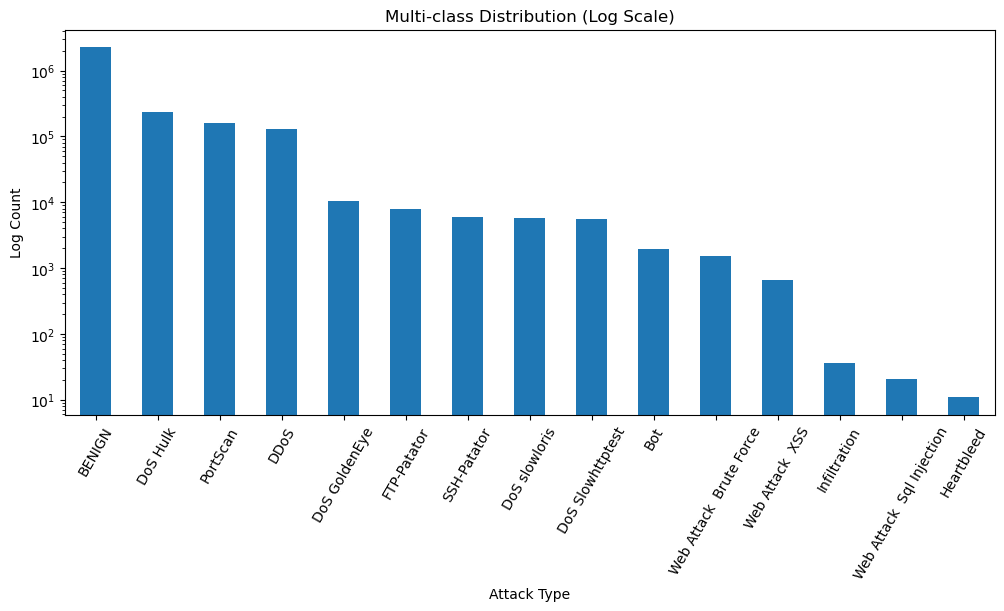

In [11]:
df['Label'].value_counts().plot(kind='bar', figsize=(12,5))

plt.yscale('log')  # KEY CHANGE

plt.title("Multi-class Distribution (Log Scale)")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=60)
plt.show()

#### Key Observations:

- The dataset is highly imbalanced, where the BENIGN class is much bigger than all other classes.
- Some attack types like DoS Hulk, PortScan and DDoS appear much more frequently compared to others.
- Other attacks such as Infiltration, SQL Injection and Heartbleed have very small number of samples.
- The use of logarithmic scale helps to visualise smaller classes which would not be visible in a normal scale.
- This imbalance can affect the machine learning model, so techniques like resampling or class weighting will be needed.
- This distribution also reflects real network traffic, where normal activity is more common and some attacks happen rarely but are still important to detect.

---

## 2.2 Correlation Analysis

A correlation matrix is used to analyse relationships between numerical features. Highly correlated features may indicate redundancy and can be removed in later stages to simplify the model and improve efficiency.

Due to the large number of features, the full correlation matrix can be difficult to interpret. Therefore, only strongly correlated features (|correlation| > 0.8) are visualised to highlight meaningful relationships and identify redundant features.

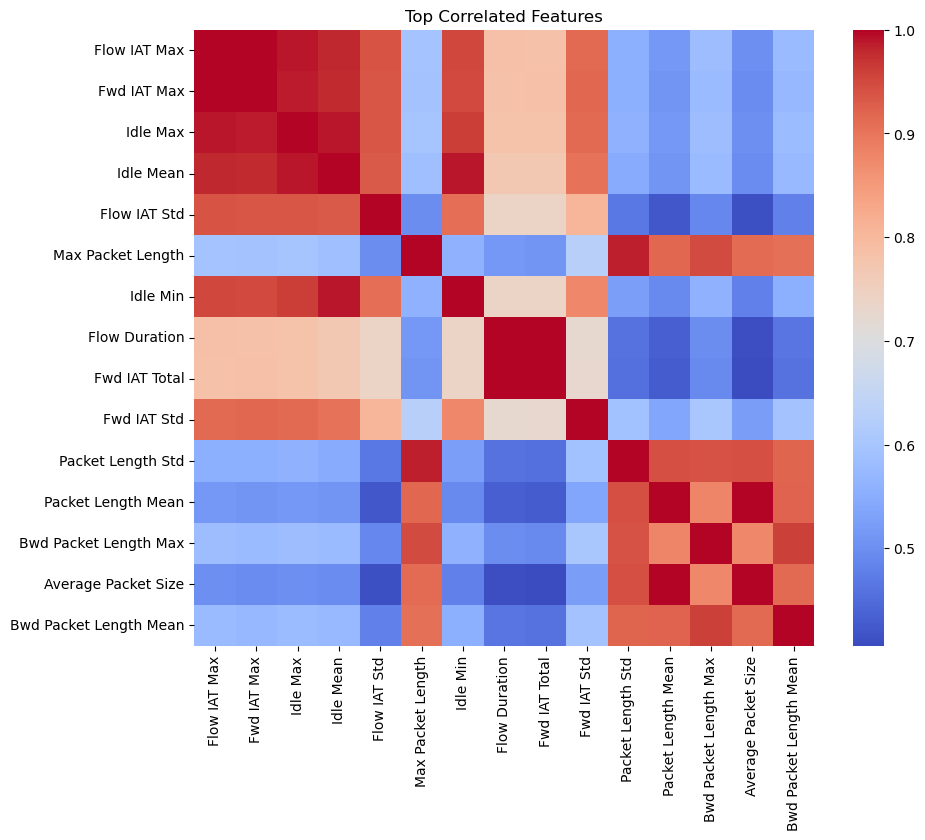

In [12]:
# Select only numerical features for correlation analysis
numeric_df = df.select_dtypes(include=['number'])

# Get top correlated features
corr_matrix = numeric_df.corr().abs()

# Select top features with highest correlation sums
top_features = corr_matrix.sum().sort_values(ascending=False).head(15).index

# Plot only those
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top_features].corr(), cmap='coolwarm')
plt.title("Top Correlated Features")
plt.show()

#### Key Observations:

- Some features show very strong correlation with each other, especially related to IAT (Inter-Arrival Time) and packet length metrics.
- Features like Flow IAT Max, Fwd IAT Max, Idle Max and Idle Mean appear highly correlated, which means they may contain similar information.
- Packet-related features such as Packet Length Mean, Packet Length Std, and Average Packet Size also show strong relationships.
- This indicates possible redundancy in the dataset, where multiple features describe similar behaviour of network traffic.
- Keeping all highly correlated features may increase model complexity without improving performance.
- Therefore, feature selection will be important.

---

## 2.3 Outlier Analysis

Boxplots are used to detect extreme values in selected features. Network traffic data naturally exhibits high variability due to differences in flow duration, packet sizes, and transmission rates.

There is no single feature that directly determines whether a flow is an attack. Instead, attacks are identified based on patterns across multiple features. Machine learning models are required to learn these multi-dimensional relationships rather than relying on predefined rules.

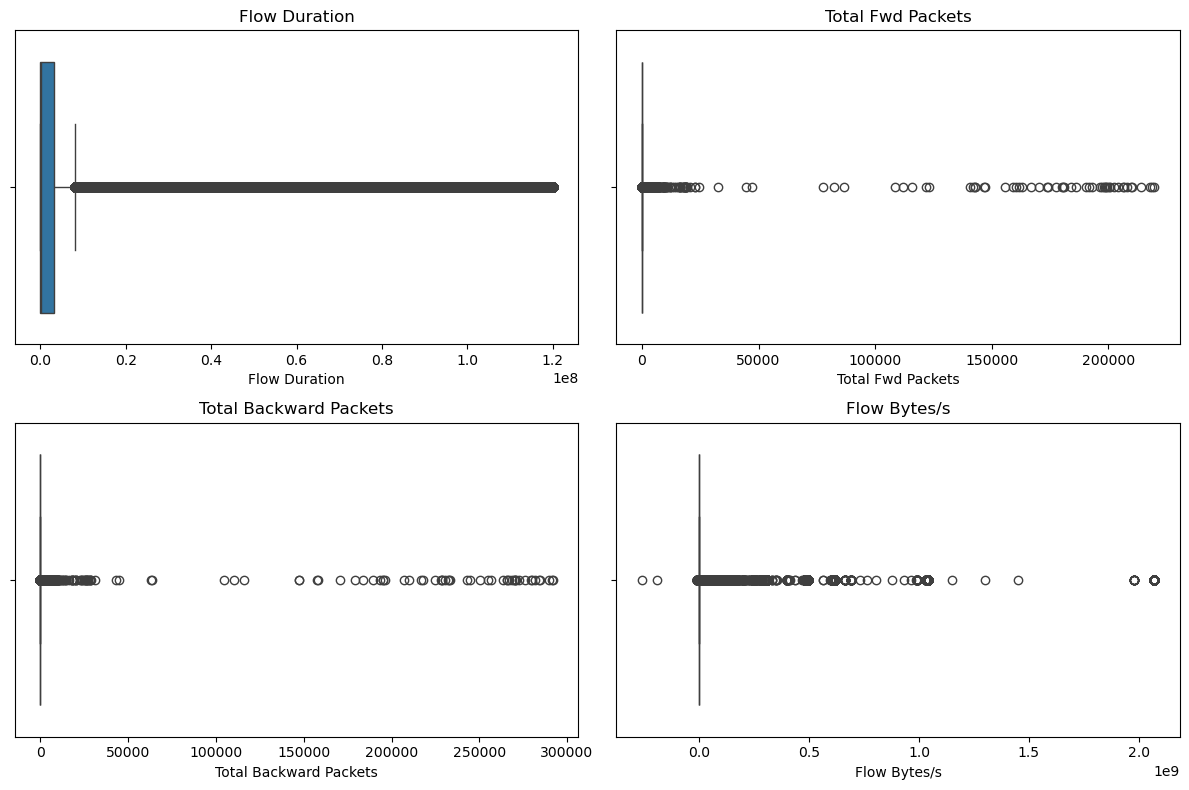

In [13]:
# Select 4 features
features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s'
]

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

#### Key Observations:

- All selected features show presence of extreme values, which appear as many points outside the boxplot range.
- Most of the data is concentrated near lower values, while a small number of observations extend to very large values.
- This indicates that the data is highly skewed, with long tails in the distribution.
- From a networking perspective, these extreme values are expected, as network traffic can vary significantly depending on the type of activity.
- Therefore, these values are not considered errors, but normal behaviour of network flows.
- However, for machine learning models, such large variations may affect performance.
- For this reason, feature scaling will be applied in the data preparation phase instead of removing these values.

---

<h1 style="text-align: center;">3. Data Cleaning</h3>

The purpose of this phase is to identify and address data quality issues that may negatively affect later preprocessing and machine learning steps.

At this stage, the cleaning process focuses on:

- detecting infinite values
- reviewing missing values after conversion
- removing incomplete records where appropriate
- identifying and removing duplicate rows
- detecting constant features that do not contribute useful information
- checking the consistency of the target labels

The goal is to improve the reliability and consistency of the dataset while preserving the behavioural patterns that are important for intrusion detection.

## 3.1 Purpose of Data Cleaning

Although the dataset has already been explored in the Data Understanding phase, the merged dataframe may still contain hidden quality issues that are common in network traffic datasets.

Cleaning is necessary before preparation because machine learning models require data that is structurally consistent, free from invalid numeric values, and suitable for later transformation steps such as encoding, scaling, and splitting.

## 3.2 Infinite Value Detection

In intrusion detection datasets, some flow-rate related features may contain infinite values. These values are not always visible in a standard missing value check, but they can break later preprocessing steps such as scaling and modelling.

For this reason, the dataset is explicitly checked for positive and negative infinite values before handling missing data.

In [14]:
import numpy as np

# Select only numerical columns for infinite value inspection
numeric_df = df.select_dtypes(include=[np.number])

# Count infinite values per numerical column
inf_mask = np.isinf(numeric_df)
inf_counts = pd.Series(inf_mask.sum(), index=numeric_df.columns)

# Display only columns that contain infinite values
inf_counts[inf_counts > 0].sort_values(ascending=False)

Flow Packets/s    2867
Flow Bytes/s      1509
dtype: int64

#### Key observations:

- Infinite values are expected mainly in rate-based features such as `Flow Bytes/s` and `Flow Packets/s`.
- These values must be addressed before missing value handling, because many machine learning tools cannot process infinite values directly.
- Converting infinite values into missing values is an appropriate intermediate step before final cleaning.

## 3.3 Missing Value Handling

After identifying infinite values, they are converted into missing values so that the dataset can be cleaned consistently.

The dataset is then rechecked for missing values. Because the number of affected records is very small relative to the total dataset size, removing incomplete rows is considered an appropriate and practical cleaning strategy at this stage.

In [15]:
# Convert positive and negative infinite values into NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Recalculate missing values after converting infinities
missing_after_inf = df.isnull().sum().sort_values(ascending=False)

# Display only columns with missing values
missing_after_inf[missing_after_inf > 0]

Flow Packets/s    2867
Flow Bytes/s      2867
dtype: int64

In [16]:
# Store the number of rows before removing missing values
rows_before_dropna = df.shape[0]

# Remove rows that contain missing values
df = df.dropna()

# Store the number of rows after removing missing values
rows_after_dropna = df.shape[0]

# Display the impact of missing value removal
print("Rows before dropping missing values:", rows_before_dropna)
print("Rows after dropping missing values:", rows_after_dropna)
print("Rows removed:", rows_before_dropna - rows_after_dropna)

Rows before dropping missing values: 2830743
Rows after dropping missing values: 2827876
Rows removed: 2867


#### Key observations:

- Missing values remain limited in proportion to the full dataset, even after converting infinite values into `NaN`.
- Since the number of affected rows is very small compared to more than 2.8 million records, removing them is unlikely to harm the overall representativeness of the dataset.
- This approach keeps the cleaning stage simple, transparent, and appropriate for the current phase of the project.

## 3.4 Duplicate Row Detection and Removal

Duplicate records can distort machine learning results by over-representing repeated patterns and inflating model performance. Since the CICIDS2017 source files are known to contain duplicates in several subsets, the merged dataframe is checked and cleaned accordingly.

In [17]:
# Count duplicate rows in the cleaned dataframe
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 307078


In [18]:
# Store the number of rows before removing duplicates
rows_before_dedup = df.shape[0]

# Remove duplicate rows
df = df.drop_duplicates()

# Store the number of rows after removing duplicates
rows_after_dedup = df.shape[0]

# Display the impact of duplicate removal
print("Rows before dropping duplicates:", rows_before_dedup)
print("Rows after dropping duplicates:", rows_after_dedup)
print("Duplicate rows removed:", rows_before_dedup - rows_after_dedup)

Rows before dropping duplicates: 2827876
Rows after dropping duplicates: 2520798
Duplicate rows removed: 307078


#### Key observations:

- Duplicate rows are present in the merged dataset and should not be ignored.
- Removing duplicates helps prevent repeated traffic records from biasing the learning process.
- This step is especially important in intrusion detection, where repeated flows can artificially strengthen certain patterns if left untreated.

## 3.5 Constant Feature Detection and Removal

Features with only one unique value do not contribute useful information for machine learning. They do not help distinguish between benign and malicious traffic and only increase the dimensionality of the dataset unnecessarily.

For this reason, the cleaned dataset is checked for constant features and such columns are removed.

In [19]:
# Identify columns that contain only one unique value
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

# Display the list of constant columns
constant_cols

['Bwd PSH Flags',
 'Bwd URG Flags',
 'Fwd Avg Bytes/Bulk',
 'Fwd Avg Packets/Bulk',
 'Fwd Avg Bulk Rate',
 'Bwd Avg Bytes/Bulk',
 'Bwd Avg Packets/Bulk',
 'Bwd Avg Bulk Rate']

In [20]:
# Display the number of constant columns
print("Number of constant columns:", len(constant_cols))

Number of constant columns: 8


In [21]:
# Remove constant columns from the dataframe
df = df.drop(columns=constant_cols)

# Display the new dataset shape after removing constant features
print("Dataset shape after removing constant columns:", df.shape)

Dataset shape after removing constant columns: (2520798, 71)


#### Key observations:

- Constant features do not provide discriminatory power for classification tasks.
- Removing them reduces unnecessary dimensionality and supports the lightweight objective of the IDS project.
- This step does not remove meaningful behavioural information, since constant variables carry no variation across the dataset.

## 3.6 Label Consistency Check

Before moving into data preparation, the target labels are reviewed to ensure that the class names remain consistent after cleaning. This helps confirm that the dataset still contains the expected multi-class structure and that no label values were unintentionally altered during the cleaning process.

In [22]:
# Standardise label formatting by removing extra internal spaces
df["Label"] = df["Label"].str.replace(r"\s+", " ", regex=True).str.strip()

In [23]:
# Display the unique target labels after cleaning
sorted(df["Label"].unique())

['BENIGN',
 'Bot',
 'DDoS',
 'DoS GoldenEye',
 'DoS Hulk',
 'DoS Slowhttptest',
 'DoS slowloris',
 'FTP-Patator',
 'Heartbleed',
 'Infiltration',
 'PortScan',
 'SSH-Patator',
 'Web Attack Brute Force',
 'Web Attack Sql Injection',
 'Web Attack XSS']

In [24]:
# Display the updated class distribution after cleaning
df["Label"].value_counts()

Label
BENIGN                      2095057
DoS Hulk                     172846
DDoS                         128014
PortScan                      90694
DoS GoldenEye                 10286
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1948
Web Attack Brute Force         1470
Web Attack XSS                  652
Infiltration                     36
Web Attack Sql Injection         21
Heartbleed                       11
Name: count, dtype: int64

#### Key observations:

- The target labels remain structurally consistent after the cleaning steps.
- Minor formatting inconsistencies in some label names were corrected.
- The dataset still preserves its multi-class structure, including both common and rare attack categories.
- This confirms that the cleaning process improved data quality without altering the core classification problem.

## 3.7 Data Cleaning Summary

The Data Cleaning phase improved the quality and consistency of the merged CICIDS2017 dataset by addressing several important issues:

- infinite values were identified and converted into missing values
- incomplete rows were removed
- duplicate records were removed
- constant features were identified and dropped
- label consistency was confirmed after cleaning

These steps make the dataset more reliable and suitable for the next phase of the project, where the cleaned data will be prepared for machine learning through encoding, feature reduction, splitting, and scaling.

---

<h1 style="text-align: center;">4. Data Preparation</h3>

## 4.1 Purpose of Data Preparation

After cleaning the dataset, the next step is to prepare it for machine learning. Preparation is necessary because most machine learning algorithms require:

- a clearly defined target variable
- numerical target labels
- predictor variables separated from the target
- reduced feature redundancy
- training and testing data in a structured format
- features on comparable numeric scales

This phase is especially important for the current project because the goal is to build a lightweight IDS, meaning that the data should not only be accurate, but also efficient and practical for modelling.

## 4.2 Target Definition

The project is currently approached as a multi-class intrusion detection problem. This means that the `Label` column is used as the target variable, where each unique value represents either benign traffic or a specific attack category.

At this stage, the goal is not to simplify the problem into binary classification, but to preserve the richer multi-class structure of the cleaned dataset for future modelling experiments.

In [25]:
# Display the target column name and the number of unique classes
print("Target column:", "Label")
print("Number of unique target classes:", df["Label"].nunique())

Target column: Label
Number of unique target classes: 15


## 4.3 Feature and Target Separation

To prepare the dataset for machine learning, the predictor variables and the target variable must be separated.

The target variable is stored in `y`, while all remaining columns are stored in `X` as input features.

In [26]:
# Separate input features (X) and target labels (y)
X = df.drop(columns=["Label"])
y = df["Label"]

# Display the shape of the feature matrix and target vector
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (2520798, 70)
Target vector shape: (2520798,)


## 4.4 Label Encoding

Machine learning algorithms require numerical target values. Since the `Label` column contains text-based class names, it must be encoded into numeric form.

A label encoder is used to convert each traffic category into a unique integer while preserving the multi-class structure of the problem.

In [27]:
from sklearn.preprocessing import LabelEncoder

# Create a label encoder object
label_encoder = LabelEncoder()

# Transform text labels into numerical class values
y_encoded = label_encoder.fit_transform(y)

# Create a mapping between original labels and encoded values
label_mapping = pd.DataFrame({
    "Original Label": label_encoder.classes_,
    "Encoded Value": label_encoder.transform(label_encoder.classes_)
})

# Display the label mapping
label_mapping

,Original Label,Encoded Value
0,BENIGN,0
1,Bot,1
2,DDoS,2
3,DoS GoldenEye,3
4,DoS Hulk,4
5,DoS Slowhttptest,5
6,DoS slowloris,6
7,FTP-Patator,7
8,Heartbleed,8
9,Infiltration,9


#### Key observations:

- Each attack category and the benign class are now represented by a unique numeric value.
- This transformation is required for later modelling with Scikit-learn algorithms.
- The original semantic meaning of each class is preserved through the label mapping table shown above.

## 4.5 Correlation-Based Feature Reduction

Even after cleaning, the dataset still contains many numerical features. Some of these features may be highly correlated and therefore redundant.

To support the lightweight objective of the IDS project, a correlation-based reduction step is applied. Features with extremely high correlation are candidates for removal because they may provide overlapping information without significantly improving the model.

In [28]:
import numpy as np

# Compute the absolute correlation matrix for the feature set
corr_matrix = X.corr().abs()

# Select the upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identify highly correlated columns above the selected threshold
high_corr_cols = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.90)]

# Display the number of highly correlated columns
print("Number of highly correlated columns to remove:", len(high_corr_cols))

# Display the first few correlated columns
high_corr_cols[:20]

Number of highly correlated columns to remove: 31


['Total Backward Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Std',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow IAT Max',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Bwd IAT Min',
 'Fwd Packets/s',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'SYN Flag Count',
 'CWE Flag Count',
 'ECE Flag Count',
 'Average Packet Size']

In [29]:
# Remove highly correlated features from the feature matrix
X_reduced = X.drop(columns=high_corr_cols)

# Display feature counts before and after correlation-based reduction
print("Original number of features:", X.shape[1])
print("Reduced number of features:", X_reduced.shape[1])

Original number of features: 70
Reduced number of features: 39


#### Key observations:

- Highly correlated features may increase dimensionality without adding much new information.
- Reducing these variables supports a more efficient and lightweight modelling pipeline.
- The reduced feature set will be used in the next preparation steps.

The correlation-based reduction was applied only to the predictor variables in `X`, not to the target variable. This ensures that redundancy is reduced in the feature space without affecting the definition of the classification task.

## 4.6 Datasets logic

After feature reduction, the notebook prepares three main dataset scenarios for modelling and evaluation:

Full Dataset:
This is the full cleaned and prepared dataset. It keeps all 15 traffic classes, including the rare attack classes such as Heartbleed, Infiltration, Web Attack Sql Injection and Web Attack XSS.

Capped Dataset:
This dataset is created from the full cleaned dataset, but each class is limited to a maximum of 10,000 records. It still keeps all 15 classes, but reduces the dominance of very large classes such as BENIGN, DoS Hulk, DDoS and PortScan. This dataset is mainly used for faster experimentation and runtime comparison.

Controlled Dataset:
This dataset is created by removing classes with fewer than 1,000 records. It reduces the classification problem from 15 classes to 11 classes. This improves metric stability, but also removes some rare attack types from the IDS training process.

For each dataset scenario, raw and scaled versions are prepared when needed. Logistic Regression uses the scaled version because it is sensitive to feature magnitude. Decision Tree and Random Forest use the raw version because tree-based models do not require scaling.

## 4.7 Full dataset (Train/Split)

Before model training, the prepared dataset must be divided into training and testing subsets.

An 80/20 split is used in this project. Stratification is applied to preserve the original class distribution as much as possible across both subsets, which is especially important in this highly imbalanced multi-class problem.

In [30]:
from sklearn.model_selection import train_test_split

# Split the reduced dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# Display the shape of each split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2016638, 39)
X_test shape: (504160, 39)
y_train shape: (2016638,)
y_test shape: (504160,)


#### Key observations:

- The dataset has now been divided into distinct training and testing subsets.
- Stratification helps preserve the relative distribution of traffic classes, which is critical in imbalanced intrusion detection data.
- This ensures that later evaluation is more realistic and methodologically sound.

## 4.8 Full Scaled Dataset

The statistical summary and outlier analysis showed that many numerical variables operate on very different scales. Some features have relatively small values, while others contain extremely large magnitudes.

To improve compatibility with machine learning algorithms, especially those sensitive to feature magnitude, standardisation is applied to the training and testing data.

In [31]:
from sklearn.preprocessing import StandardScaler

# Create a scaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the shape of the scaled datasets
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (2016638, 39)
Scaled X_test shape: (504160, 39)


#### Key observations:

- Feature scaling does not change the meaning of the variables, but it makes them comparable in magnitude.
- This is particularly important for models that rely on distances, gradients, or optimisation procedures.
- The dataset is now in a more suitable form for machine learning experiments.

The scaler was fitted only on the training data and then applied to the test data. This avoids data leakage and ensures a more valid evaluation setup for the modelling phase.

## 4.9 Capped Dataset

The capped dataset is created from the full cleaned dataset. It keeps all 15 traffic classes, but limits each class to a maximum of 10,000 records.

This was done to reduce the dominance of very large classes such as BENIGN, DoS Hulk, DDoS and PortScan, while still keeping the rare attack classes in the dataset.

The capped dataset makes experimentation faster and more practical because the full dataset has more than 2.5 million rows. It is useful for comparing models and training times under a smaller dataset scenario.

However, the capped dataset changes the original class distribution. For this reason, it is not treated as the main final evaluation dataset. It is mainly used for lightweight experimentation and comparison.

In [32]:
# Create capped dataset from cleaned dataset
max_samples_per_class = 10000

capped_df = pd.concat([
    group.sample(
        n=min(len(group), max_samples_per_class),
        random_state=42
    )
    for _, group in df.groupby("Label")
]).reset_index(drop=True)

# Separate features and target
X_capped = capped_df.drop(columns=["Label"])

# Apply the same correlation-based feature reduction used in the full dataset
cols_to_drop_capped = [col for col in high_corr_cols if col in X_capped.columns]
X_capped_reduced = X_capped.drop(columns=cols_to_drop_capped)

# Encode target labels
label_encoder_capped = LabelEncoder()
y_capped = label_encoder_capped.fit_transform(capped_df["Label"])

# Train/Test split
X_train_capped, X_test_capped, y_train_capped, y_test_capped = train_test_split(
    X_capped_reduced,
    y_capped,
    test_size=0.2,
    stratify=y_capped,
    random_state=42
)

# Scale capped dataset for Logistic Regression
scaler_capped = StandardScaler()

X_train_capped_scaled = scaler_capped.fit_transform(X_train_capped)
X_test_capped_scaled = scaler_capped.transform(X_test_capped)

# Display capped class distribution
capped_df["Label"].value_counts()

Label
BENIGN                      10000
DDoS                        10000
DoS GoldenEye               10000
DoS Hulk                    10000
PortScan                    10000
FTP-Patator                  5931
DoS slowloris                5385
DoS Slowhttptest             5228
SSH-Patator                  3219
Bot                          1948
Web Attack Brute Force       1470
Web Attack XSS                652
Infiltration                   36
Web Attack Sql Injection       21
Heartbleed                     11
Name: count, dtype: int64

In [33]:
print("Original capped feature count:", X_capped.shape[1])
print("Reduced capped feature count:", X_capped_reduced.shape[1])

Original capped feature count: 70
Reduced capped feature count: 39


#### Key observations:

- The capped dataset keeps all 15 original traffic classes.
- The majority classes were limited to 10,000 records each.
- Rare classes such as Heartbleed, Infiltration, Web Attack Sql Injection and Web Attack XSS were not removed.
- This makes the capped dataset different from the controlled dataset.
- The capped dataset is useful for faster model testing, but it does not fully represent the original traffic distribution because the largest classes were artificially reduced.

## 4.10 Controlled Dataset

During the initial multiclass preparation, the dataset preserved all 15 traffic classes. However, some attack categories have extremely low support after cleaning, such as Heartbleed, Infiltration, Web Attack Sql Injection and Web Attack XSS.

These classes are not incorrect data. However, because they contain very few samples, they are difficult to train and evaluate reliably. Keeping extremely rare classes may introduce noise and unstable results in the modelling phase.

For this reason, a controlled multiclass dataset is created by removing classes with fewer than 1000 records after cleaning. This keeps the project focused on multiclass intrusion detection while improving the reliability of model comparison and evaluation.

This creates a more stable dataset for evaluation, but it also introduces an important limitation. The removed classes are still valid attack types. Therefore, any model trained only on the controlled dataset will not be able to detect those removed attack categories. For this reason, the controlled dataset is useful for comparison and stability, but the final model selection also needs to consider attack coverage.

In [34]:
# Check class distribution after cleaning
class_counts_cleaned = df["Label"].value_counts()

# Define minimum number of records required to keep a class
min_class_samples = 1000

# Identify rare classes with fewer than the selected threshold
rare_classes = class_counts_cleaned[class_counts_cleaned < min_class_samples].index.tolist()

# Display rare classes to be removed
print("Minimum samples required:", min_class_samples)
print("Rare classes to remove:", rare_classes)

class_counts_cleaned[class_counts_cleaned < min_class_samples]

Minimum samples required: 1000
Rare classes to remove: ['Web Attack XSS', 'Infiltration', 'Web Attack Sql Injection', 'Heartbleed']


Label
Web Attack XSS              652
Infiltration                 36
Web Attack Sql Injection     21
Heartbleed                   11
Name: count, dtype: int64

In [35]:
# Create controlled multiclass dataframe by removing rare classes
df_controlled = df[~df["Label"].isin(rare_classes)].copy()

print("Original cleaned dataset shape:", df.shape)
print("Controlled multiclass dataset shape:", df_controlled.shape)
print("Number of classes before:", df["Label"].nunique())
print("Number of classes after:", df_controlled["Label"].nunique())

# Display new class distribution
df_controlled["Label"].value_counts()

Original cleaned dataset shape: (2520798, 71)
Controlled multiclass dataset shape: (2520078, 71)
Number of classes before: 15
Number of classes after: 11


Label
BENIGN                    2095057
DoS Hulk                   172846
DDoS                       128014
PortScan                    90694
DoS GoldenEye               10286
FTP-Patator                  5931
DoS slowloris                5385
DoS Slowhttptest             5228
SSH-Patator                  3219
Bot                          1948
Web Attack Brute Force       1470
Name: count, dtype: int64

#### Key observations:

The controlled multiclass dataset removes only classes with extremely low support. This decision does not treat these attacks as invalid, but recognises that there are not enough samples to train and evaluate them reliably.

The remaining dataset still preserves the multiclass IDS objective, including benign traffic and the main attack categories. This supports a more stable comparison between machine learning models.

## 4.11 Controlled Dataset Feature and Target Preparation

After creating the controlled multiclass dataset, the predictor variables and target variable are prepared again. A new label encoder is used because the number of classes has changed after removing extremely rare categories.

The same correlation-based feature reduction list from the previous preparation stage is applied to keep the modelling pipeline consistent and lightweight.

In [36]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target for the controlled multiclass dataset
X_controlled = df_controlled.drop(columns=["Label"])
y_controlled = df_controlled["Label"]

# Encode controlled target labels
label_encoder_controlled = LabelEncoder()
y_controlled_encoded = label_encoder_controlled.fit_transform(y_controlled)

# Display new label mapping
label_mapping_controlled = pd.DataFrame({
    "Original Label": label_encoder_controlled.classes_,
    "Encoded Value": label_encoder_controlled.transform(label_encoder_controlled.classes_)
})

label_mapping_controlled

,Original Label,Encoded Value
0,BENIGN,0
1,Bot,1
2,DDoS,2
3,DoS GoldenEye,3
4,DoS Hulk,4
5,DoS Slowhttptest,5
6,DoS slowloris,6
7,FTP-Patator,7
8,PortScan,8
9,SSH-Patator,9


In [37]:
# Apply the same correlation-based feature reduction to the controlled dataset
cols_to_drop_controlled = [col for col in high_corr_cols if col in X_controlled.columns]

X_controlled_reduced = X_controlled.drop(columns=cols_to_drop_controlled)

print("Original controlled feature count:", X_controlled.shape[1])
print("Reduced controlled feature count:", X_controlled_reduced.shape[1])

Original controlled feature count: 70
Reduced controlled feature count: 39


The same highly correlated features identified earlier were removed from the controlled dataset. This keeps the feature space consistent and supports the lightweight objective of the IDS prototype.

In [38]:
# Split controlled dataset into training and testing sets
X_train_ctrl, X_test_ctrl, y_train_ctrl, y_test_ctrl = train_test_split(
    X_controlled_reduced,
    y_controlled_encoded,
    test_size=0.2,
    stratify=y_controlled_encoded,
    random_state=42
)

print("X_train_ctrl shape:", X_train_ctrl.shape)
print("X_test_ctrl shape:", X_test_ctrl.shape)
print("y_train_ctrl shape:", y_train_ctrl.shape)
print("y_test_ctrl shape:", y_test_ctrl.shape)

X_train_ctrl shape: (2016062, 39)
X_test_ctrl shape: (504016, 39)
y_train_ctrl shape: (2016062,)
y_test_ctrl shape: (504016,)


Stratification is applied again to preserve the class distribution in both training and testing sets. This is important because the controlled dataset still remains imbalanced, even after removing extremely rare classes.

In [39]:
# Scale controlled dataset for models that are sensitive to feature magnitude
scaler_controlled = StandardScaler()

X_train_ctrl_scaled = scaler_controlled.fit_transform(X_train_ctrl)
X_test_ctrl_scaled = scaler_controlled.transform(X_test_ctrl)

print("Scaled controlled training shape:", X_train_ctrl_scaled.shape)
print("Scaled controlled testing shape:", X_test_ctrl_scaled.shape)

Scaled controlled training shape: (2016062, 39)
Scaled controlled testing shape: (504016, 39)


Feature scaling is applied for Logistic Regression because this model is sensitive to feature magnitude. Decision Tree models do not require scaling, so they will be trained using the non-scaled controlled dataset.

---

## 4.12 Class Imbalance Considerations

Although the dataset has now been cleaned and prepared structurally, it still remains highly imbalanced in the multi-class setting.

This is an important consideration for the modelling phase, because highly frequent classes such as `BENIGN`, `DoS Hulk`, and `DDoS` may dominate the learning process, while rare attack categories may be harder to predict correctly.

At this stage, no balancing technique is applied yet. However, future modelling experiments may consider:

- class weighting
- SMOTE or related methods
- evaluation metrics beyond simple accuracy

---

## 4.13 Data Preparation Summary

The Data Preparation phase transformed the cleaned CICIDS2017 dataset into multiple structured datasets suitable for machine learning experimentation and comparison.

The following preparation steps were completed:

- the target variable was defined as a multi-class traffic label  
- the feature matrix and target vector were separated  
- the target labels were encoded numerically  
- highly correlated features were reduced using correlation-based feature selection  
- the dataset was split into training and testing subsets using stratified sampling  
- feature scaling was applied for models sensitive to feature magnitude  
- a capped dataset was created by limiting each class to a maximum of 10,000 samples  
- a controlled multiclass dataset was created by removing classes with fewer than 1,000 records  
- both raw and scaled versions of the datasets were prepared for different machine learning algorithms  
- class imbalance and rare attack categories were identified as important modelling challenges  

At the end of this phase, three main dataset scenarios were available for modelling and evaluation:

**Full Prepared Dataset**
   - 15 classes
   - Approximately 2.52 million rows
   - Keeps all attack categories, including rare classes

**Capped Stratified Dataset**
   - 15 classes
   - Maximum of 10,000 records per class
   - Used for faster and more practical model comparison

**Controlled Dataset**
   - 11 classes
   - Removes classes with fewer than 1,000 records
   - Used to test model performance after removing extremely rare classes


Raw and scaled versions were prepared for these datasets. Raw versions were used for Decision Tree and Random Forest, while scaled versions were mainly used for Logistic Regression.

---

<h1 style="text-align: center;">5. Metrics and Evaluation Function</h3>

The modelling and evaluation sections compare Logistic Regression, Decision Tree and Random Forest across three dataset scenarios: Full Dataset, Capped Dataset and Controlled Dataset.

The Full Dataset keeps all 15 traffic classes and provides the widest attack coverage. The Capped Dataset also keeps all 15 classes, but limits each class to a maximum of 10,000 records to support faster experimentation. The Controlled Dataset removes classes with fewer than 1,000 records, reducing the problem to 11 classes and improving metric stability.

For each model, baseline and balanced versions are tested where appropriate. In this project, baseline means the model is trained without class_weight="balanced". Balanced means the model uses class_weight="balanced" to give more importance to minority classes during training.

The purpose of this evaluation is to understand model performance, minority-class detection, training time, interpretability and suitability for a lightweight IDS prototype.

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import time

# Store results, predictions and trained models
model_results = []
model_predictions = {}
trained_models = {}

def evaluate_classification_model(model_name, model_version, model,
                                  X_train_data, X_test_data,
                                  y_train_data, y_test_data,
                                  target_names):

    start_time = time.time()

    # Train model
    model.fit(X_train_data, y_train_data)

    # Predict test set
    y_pred = model.predict(X_test_data)

    end_time = time.time()
    training_time = end_time - start_time

    # Calculate metrics
    accuracy = accuracy_score(y_test_data, y_pred)
    macro_precision = precision_score(y_test_data, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test_data, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test_data, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test_data, y_pred, average="weighted", zero_division=0)

    # Store model key
    model_key = model_name + " - " + model_version

    # Avoid duplicated results if the same model is run more than once
    model_results[:] = [
        m for m in model_results
        if m["Model Key"] != model_key
    ]

    # Store results
    model_results.append({
        "Model Key": model_key,
        "Model": model_name,
        "Version": model_version,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1-score": macro_f1,
        "Weighted F1-score": weighted_f1,
        "Training Time (seconds)": training_time
    })

    # Store predictions and trained model
    model_predictions[model_key] = y_pred
    trained_models[model_key] = model

    # Display results
    print(model_key)
    print("Training time:", round(training_time, 2), "seconds")
    print(classification_report(
        y_test_data,
        y_pred,
        target_names=target_names,
        zero_division=0
    ))

    return y_pred

The evaluation function calculates several metrics instead of relying only on accuracy. This is important because accuracy can be misleading in imbalanced intrusion detection datasets. Macro recall and macro F1-score are especially useful because they treat each class more equally.

### Baseline and Balanced Model Configuration

In this notebook, baseline and balanced refer to model configuration, not to the dataset itself.

A baseline model is trained without class_weight="balanced". This means all classes are treated equally by the algorithm during training.

A balanced model uses class_weight="balanced". This gives more importance to minority classes and can improve recall for rare attacks. However, it can also reduce precision and increase false positives.

Therefore, baseline and balanced versions are compared to understand whether class weighting improves IDS performance.

---

<h1 style="text-align: center;">6. Random Forest Modelling</h3>


Random Forest is an ensemble machine learning algorithm that uses many Decision Trees together. Each tree learns from a different sample of the training data, and the final prediction is made by majority voting between the trees.

This model is useful for intrusion detection because it can handle many numerical features, works well with non-scaled data, and is less sensitive to outliers. In this project, Random Forest was tested using the raw dataset versions because tree-based models do not require feature scaling.

<h3>6.1 Random Forest - Full Dataset</h3>

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest - Full Dataset
rf_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_full_pred = evaluate_classification_model(
    "Random Forest",
    "Full Dataset",
    rf_full,
    X_train,
    X_test,
    y_train,
    y_test,
    label_encoder.classes_
)

Random Forest - Full Dataset
Training time: 76.26 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    419012
                     Bot       0.89      0.78      0.83       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       1.00      0.99      1.00      2057
                DoS Hulk       1.00      1.00      1.00     34569
        DoS Slowhttptest       0.99      1.00      0.99      1046
           DoS slowloris       1.00      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      0.50      0.67         2
            Infiltration       1.00      1.00      1.00         7
                PortScan       0.99      0.99      0.99     18139
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.74      0.84      0.79       294
Web Attack Sql In

<h3>6.2 Random Forest - Full Dataset Balanced</h3>

In [42]:
# Random Forest - Full Dataset with Balanced Class Weight
rf_full_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_full_balanced_pred = evaluate_classification_model(
    "Random Forest",
    "Full Dataset Balanced",
    rf_full_balanced,
    X_train,
    X_test,
    y_train,
    y_test,
    label_encoder.classes_
)

Random Forest - Full Dataset Balanced
Training time: 71.72 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    419012
                     Bot       0.89      0.77      0.82       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       1.00      0.99      1.00      2057
                DoS Hulk       1.00      1.00      1.00     34569
        DoS Slowhttptest       0.99      1.00      0.99      1046
           DoS slowloris       1.00      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      0.50      0.67         2
            Infiltration       1.00      1.00      1.00         7
                PortScan       0.99      0.99      0.99     18139
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.73      0.85      0.79       294
Web Atta

### Random Forest — Full Dataset vs Balanced Version

On the entire dataset, the Random Forest models were excellent in performance, enjoying high-weighted metrics, and generally good classifying results across virtually all traffic classification types.

With the balanced model, we only saw slight improvement from baseline metrics; macro-precision and minority-class prediction results were nearly identical to those of the baseline Random Forest, indicating that the Random Forest was capable of efficiently handling the dataset imbalance.

Some extremely rare classes (e.g., Web Attack Sql Injection and Web Attack XSS) were still difficult to consistently classify due to low sample sizes of both classes.

Overall, the balanced Random Forest did not show any significant improvements over baseline results; therefore, it can be concluded that the baseline Random Forest algorithm was able to handle the multiclass IDS dataset very well.

---

<h3>6.3 Random Forest - Capped Dataset</h3>

In [43]:
# Random Forest - Capped  Dataset
rf_capped = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_capped_pred = evaluate_classification_model(
    "Random Forest",
    "Capped Dataset",
    rf_capped,
    X_train_capped,
    X_test_capped,
    y_train_capped,
    y_test_capped,
    label_encoder_capped.classes_
)

Random Forest - Capped Dataset
Training time: 1.09 seconds
                          precision    recall  f1-score   support

                  BENIGN       0.99      1.00      1.00      2000
                     Bot       0.99      0.99      0.99       390
                    DDoS       1.00      1.00      1.00      2000
           DoS GoldenEye       1.00      1.00      1.00      2000
                DoS Hulk       1.00      1.00      1.00      2000
        DoS Slowhttptest       1.00      0.99      1.00      1046
           DoS slowloris       0.99      1.00      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      0.86      0.92         7
                PortScan       1.00      1.00      1.00      2000
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.74      0.81      0.77       294
Web Attack Sql I

<h3>6.4 Random Forest - Capped Dataset Balancing Classes</h3>

In [44]:
# Random Forest Balanced - Capped Dataset
rf_capped_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_capped_balanced_pred = evaluate_classification_model(
    "Random Forest",
    "Capped Dataset Balanced",
    rf_capped_balanced,
    X_train_capped,
    X_test_capped,
    y_train_capped,
    y_test_capped,
    label_encoder_capped.classes_
)

Random Forest - Capped Dataset Balanced
Training time: 1.23 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00      2000
                     Bot       0.99      0.99      0.99       390
                    DDoS       1.00      1.00      1.00      2000
           DoS GoldenEye       1.00      1.00      1.00      2000
                DoS Hulk       1.00      1.00      1.00      2000
        DoS Slowhttptest       1.00      0.99      0.99      1046
           DoS slowloris       0.99      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      0.86      0.92         7
                PortScan       1.00      1.00      1.00      2000
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.74      0.82      0.78       294
Web Att

### Random Forest — Capped Dataset Comparison

The accuracy of both models built with Random Forest was very good for the capped version of the datasets and achieved a low training time compared to their full dataset versions.

The balanced versions of the Random Forest models only showed minimal difference when considering a reduction in class imbalance, demonstrating that Random Forest can effectively manage class imbalance without the use of any additional weighting.

The capped datasets appreciably reduced the computational cost of building a model and also allowed faster model training. However, by limiting the majority classes to 10,000 records, the capped dataset artificially changes the original class distribution. This can create biased results that do not fully represent real network traffic in the real world.

Therefore, the capped dataset was considered useful mainly for lightweight experimentation and runtime comparison, but not as the main final evaluation scenario for the IDS.

---

<h3>6.5 Random Forest - Controlled Dataset</h3>

In [45]:
# Random Forest - Controlled Dataset
rf_controlled = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_controlled_pred = evaluate_classification_model(
    "Random Forest",
    "Controlled Dataset",
    rf_controlled,
    X_train_ctrl,
    X_test_ctrl,
    y_train_ctrl,
    y_test_ctrl,
    label_encoder_controlled.classes_
)

Random Forest - Controlled Dataset
Training time: 74.57 seconds
                        precision    recall  f1-score   support

                BENIGN       1.00      1.00      1.00    419012
                   Bot       0.89      0.78      0.83       389
                  DDoS       1.00      1.00      1.00     25603
         DoS GoldenEye       1.00      0.99      1.00      2057
              DoS Hulk       1.00      1.00      1.00     34569
      DoS Slowhttptest       0.99      1.00      0.99      1046
         DoS slowloris       1.00      0.99      0.99      1077
           FTP-Patator       1.00      1.00      1.00      1186
              PortScan       0.99      0.99      0.99     18139
           SSH-Patator       1.00      1.00      1.00       644
Web Attack Brute Force       0.99      0.99      0.99       294

              accuracy                           1.00    504016
             macro avg       0.99      0.98      0.98    504016
          weighted avg       1.00     

<h3>6.6 Random Forest - Balanced Model Balancing Classes</h3>

In [46]:
# Random Forest Balanced - Controlled Dataset
rf_controlled_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_controlled_balanced_pred = evaluate_classification_model(
    "Random Forest",
    "Controlled Dataset Balanced",
    rf_controlled_balanced,
    X_train_ctrl,
    X_test_ctrl,
    y_train_ctrl,
    y_test_ctrl,
    label_encoder_controlled.classes_
)

Random Forest - Controlled Dataset Balanced
Training time: 66.56 seconds
                        precision    recall  f1-score   support

                BENIGN       1.00      1.00      1.00    419012
                   Bot       0.89      0.77      0.83       389
                  DDoS       1.00      1.00      1.00     25603
         DoS GoldenEye       1.00      0.99      1.00      2057
              DoS Hulk       1.00      1.00      1.00     34569
      DoS Slowhttptest       0.99      1.00      0.99      1046
         DoS slowloris       0.99      0.99      0.99      1077
           FTP-Patator       1.00      1.00      1.00      1186
              PortScan       0.99      0.99      0.99     18139
           SSH-Patator       1.00      1.00      1.00       644
Web Attack Brute Force       0.98      0.98      0.98       294

              accuracy                           1.00    504016
             macro avg       0.99      0.97      0.98    504016
          weighted avg       

### Random Forest — Controlled Dataset Comparison

The Controlled Dataset's performance was extremely robust, producing high macro average and weighted scores across nearly every traffic class.

The balanced model did not significantly differ from the baseline model, indicating that most of the problem with imbalance was rectified with the removal of the very rare classes prior to developing either dataset.

In contrast to the Capped Dataset, the Controlled Dataset provides a more stable evaluation scenario because the majority classes were not artificially limited. However, it still has lower attack coverage because the rare classes were removed. For this reason, the Controlled Dataset is useful for comparison and stability, but it should not automatically be treated as the best final IDS scenario.

In summary, the Controlled Dataset models produced the strongest Random Forest results in terms of Macro F1-score. However, they are treated as benchmark models rather than the final IDS choice because the controlled dataset removes four rare attack classes.

---

In [47]:
rf_results = pd.DataFrame(model_results)

rf_results[rf_results["Model"] == "Random Forest"]

,Model Key,Model,Version,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score,Training Time (seconds)
0,Random Forest - Full Dataset,Random Forest,Full Dataset,0.998360,0.936678,0.841305,0.866682,0.998327,76.264055
1,Random Forest - Full Dataset Balanced,Random Forest,Full Dataset Balanced,0.998381,0.937933,0.840933,0.866676,0.998347,71.720585
2,Random Forest - Capped Dataset,Random Forest,Capped Dataset,0.988431,0.945360,0.900638,0.916580,0.988055,1.090462
3,Random Forest - Capped Dataset Balanced,Random Forest,Capped Dataset Balanced,0.988296,0.945059,0.883821,0.898445,0.987847,1.229833
4,Random Forest - Controlled Dataset,Random Forest,Controlled Dataset,0.998659,0.986462,0.975224,0.980467,0.998650,74.565284
5,Random Forest - Controlled Dataset Balanced,Random Forest,Controlled Dataset Balanced,0.998663,0.986000,0.974516,0.979868,0.998654,66.563557


### Random Forest Overall Analysis

Overall, the Random Forest models achieved very strong results across all dataset strategies, especially in weighted metrics and minority-class detection.

Although the capped dataset produced very fast training times, this approach artificially changes the original class distribution and may introduce bias. Therefore, it was considered more suitable for lightweight experimentation rather than final evaluation.

Between the Random Forest approaches, the Controlled Dataset models produced the strongest macro F1-scores. The baseline Controlled Dataset version achieved a slightly higher Macro F1-score than the balanced version, while the balanced version had a slightly lower training time.

This shows that class weighting did not significantly improve Random Forest performance in this project. The controlled dataset itself already improved metric stability by removing extremely rare classes.

Therefore, the Controlled Dataset Random Forest models are kept as strong benchmark models, but Random Forest was not selected as the final model because it had higher training time than the tuned Decision Tree model.

---

<h1 style="text-align: center;">7. Decision Tree Modelling</h3>

Decision Tree is a supervised machine learning algorithm that makes predictions by splitting the dataset into smaller decision rules. Each split is based on feature values, and the final class is predicted at the leaf node.

This model is useful for this IDS project because it is simple to understand, fast to train, and does not require feature scaling. This makes it a good option for a lightweight intrusion detection system.

<h3>7.1 Decision Tree - Full Dataset</h3>

In [48]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree - Full Dataset
dt_full = DecisionTreeClassifier(
    random_state=42
)

dt_full_pred = evaluate_classification_model(
    "Decision Tree",
    "Full Dataset",
    dt_full,
    X_train,
    X_test,
    y_train,
    y_test,
    label_encoder.classes_
)

Decision Tree - Full Dataset
Training time: 52.45 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    419012
                     Bot       0.82      0.85      0.84       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       1.00      0.99      0.99      2057
                DoS Hulk       1.00      1.00      1.00     34569
        DoS Slowhttptest       0.98      0.99      0.99      1046
           DoS slowloris       0.99      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      0.50      0.67         2
            Infiltration       0.75      0.86      0.80         7
                PortScan       0.99      0.98      0.99     18139
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.73      0.74      0.74       294
Web Attack Sql In

<h3>7.2 Decision Tree - Full Dataset Balancing Classes</h3>

In [49]:
# Decision Tree Balanced - Full Dataset
dt_full_balanced = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt_full_balanced_pred = evaluate_classification_model(
    "Decision Tree",
    "Full Dataset Balanced",
    dt_full_balanced,
    X_train,
    X_test,
    y_train,
    y_test,
    label_encoder.classes_
)

Decision Tree - Full Dataset Balanced
Training time: 34.67 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    419012
                     Bot       0.82      0.82      0.82       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       1.00      0.99      0.99      2057
                DoS Hulk       1.00      1.00      1.00     34569
        DoS Slowhttptest       0.99      0.99      0.99      1046
           DoS slowloris       0.99      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      0.86      0.92         7
                PortScan       0.99      0.99      0.99     18139
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.73      0.79      0.76       294
Web Atta

### Decision Tree — Full Dataset vs Balanced Version

Both Decision Tree models performed very well in terms of overall accuracy. However, because the dataset is highly imbalanced, accuracy alone is not enough to evaluate IDS performance.

For this reason, macro precision, macro recall and macro F1-score are more useful because they give more importance to minority classes.

The Balanced Decision Tree improved the baseline Decision Tree in terms of macro precision, macro recall and macro F1-score. Some rare attack classes, such as Heartbleed and Infiltration, also improved when class_weight="balanced" was applied.

However, extremely rare classes such as Web Attack Sql Injection and Web Attack XSS were still difficult to classify consistently because they have very low support.

Overall, the Balanced Decision Tree performed better than the baseline version for minority-class detection, while also keeping a lower training time.

---

<h3>7.3 Decision Tree - Capped Dataset</h3>

In [50]:
# Decision Tree - Capped Dataset
dt_capped = DecisionTreeClassifier(
    random_state=42
)

dt_capped_pred = evaluate_classification_model(
    "Decision Tree",
    "Capped Dataset",
    dt_capped,
    X_train_capped,
    X_test_capped,
    y_train_capped,
    y_test_capped,
    label_encoder_capped.classes_
)

Decision Tree - Capped Dataset
Training time: 0.58 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      0.99      0.99      2000
                     Bot       0.99      0.98      0.99       390
                    DDoS       1.00      1.00      1.00      2000
           DoS GoldenEye       1.00      1.00      1.00      2000
                DoS Hulk       1.00      1.00      1.00      2000
        DoS Slowhttptest       0.99      1.00      0.99      1046
           DoS slowloris       0.99      1.00      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      1.00      1.00         7
                PortScan       1.00      1.00      1.00      2000
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.73      0.65      0.68       294
Web Attack Sql I

<h3>7.4 Decision Tree - Capped Dataset Balancing Classes</h3>

In [51]:
# Decision Tree Balanced - Capped Dataset
dt_capped_balanced = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt_capped_balanced_pred = evaluate_classification_model(
    "Decision Tree",
    "Capped Dataset Balanced",
    dt_capped_balanced,
    X_train_capped,
    X_test_capped,
    y_train_capped,
    y_test_capped,
    label_encoder_capped.classes_
)

Decision Tree - Capped Dataset Balanced
Training time: 0.69 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      0.99      1.00      2000
                     Bot       0.99      1.00      1.00       390
                    DDoS       1.00      1.00      1.00      2000
           DoS GoldenEye       1.00      1.00      1.00      2000
                DoS Hulk       1.00      1.00      1.00      2000
        DoS Slowhttptest       0.99      0.99      0.99      1046
           DoS slowloris       0.99      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      1.00      1.00         7
                PortScan       1.00      1.00      1.00      2000
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.72      0.68      0.70       294
Web Att

### Decision Tree — Capped Dataset Balanced

Both the Decision Tree models had excellent results on the capped dataset with high-weighted metrics and short training time.

The balanced version had slightly higher macro precision and macro F1-score, so it was able to handle the minority attack classes slightly better than the unbalanced version. There are still a few rare categories such as Web Attack Sql Injection and Web Attack XSS that cannot consistently have their instances classified correctly because they contain so few instances.

The capped dataset also significantly reduced the computational cost of training the models compared to the entire dataset while still providing good classification results.

However, there may be some bias in the capped strategy because the class distribution from the uncapped versions of the models is modified from its original state. In the original dataset, the most prevalent class is BENIGN traffic, which accounts for the majority of the flow in the dataset. The capped dataset created by restricting the maximum number of instances per class reduces this discrepancy.

Despite these disadvantages, using the capped dataset is very practical for lightweight experimentation and comparisons between multiple models due to its reduced training times and manageable dataset sizes.

---

<h3>7.5 Decision Tree - Controlled Dataset</h3>

In [52]:
# Decision Tree - Controlled Dataset
dt_controlled = DecisionTreeClassifier(
    random_state=42
)

dt_controlled_pred = evaluate_classification_model(
    "Decision Tree",
    "Controlled Dataset",
    dt_controlled,
    X_train_ctrl,
    X_test_ctrl,
    y_train_ctrl,
    y_test_ctrl,
    label_encoder_controlled.classes_
)

Decision Tree - Controlled Dataset
Training time: 48.36 seconds
                        precision    recall  f1-score   support

                BENIGN       1.00      1.00      1.00    419012
                   Bot       0.83      0.85      0.84       389
                  DDoS       1.00      1.00      1.00     25603
         DoS GoldenEye       0.99      0.99      0.99      2057
              DoS Hulk       1.00      1.00      1.00     34569
      DoS Slowhttptest       0.99      0.99      0.99      1046
         DoS slowloris       0.99      0.99      0.99      1077
           FTP-Patator       1.00      1.00      1.00      1186
              PortScan       0.99      0.98      0.99     18139
           SSH-Patator       1.00      1.00      1.00       644
Web Attack Brute Force       0.97      0.98      0.98       294

              accuracy                           1.00    504016
             macro avg       0.98      0.98      0.98    504016
          weighted avg       1.00     

<h3>7.6 Decision Tree - Balanced Model Balancing Classes</h3>

In [53]:
# Decision Tree Balanced - Controlled Dataset
dt_controlled_balanced = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt_controlled_balanced_pred = evaluate_classification_model(
    "Decision Tree",
    "Controlled Dataset Balanced",
    dt_controlled_balanced,
    X_train_ctrl,
    X_test_ctrl,
    y_train_ctrl,
    y_test_ctrl,
    label_encoder_controlled.classes_
)

Decision Tree - Controlled Dataset Balanced
Training time: 31.63 seconds
                        precision    recall  f1-score   support

                BENIGN       1.00      1.00      1.00    419012
                   Bot       0.84      0.83      0.83       389
                  DDoS       1.00      1.00      1.00     25603
         DoS GoldenEye       1.00      0.99      1.00      2057
              DoS Hulk       1.00      1.00      1.00     34569
      DoS Slowhttptest       0.99      0.99      0.99      1046
         DoS slowloris       0.99      0.99      0.99      1077
           FTP-Patator       1.00      1.00      1.00      1186
              PortScan       0.99      0.99      0.99     18139
           SSH-Patator       1.00      1.00      1.00       644
Web Attack Brute Force       0.98      0.98      0.98       294

              accuracy                           1.00    504016
             macro avg       0.98      0.98      0.98    504016
          weighted avg       

### Decision Tree — Controlled Dataset Comparison

With the extremely rare traffic classes removed before training, it was found that the controlled dataset provided more stable and reliable results than did the full dataset (original).

A strong performance was demonstrated by both of the Decision Tree models used in this study, with most of the attack classification metrics yielding high-macro average and weighted values. The balanced version of the dataset exhibited only marginal differences from that of the baseline model, suggesting that some of the data imbalance issue was addressed with the controlled dataset due to the removal of classes with very low support.

Developing the controlled dataset reduced the complexity of the models, while maintaining the multiclass structure of the IDS. This provided improved balance among computational efficiency, minority-class reliability, and the overall reliability of the model.

In comparison to the capped dataset, the controlled dataset keeps the original distribution of the remaining 11 classes better because the majority classes were not artificially limited. Therefore, it provides a more stable evaluation scenario for the remaining classes. However, it still has lower attack coverage because four rare attack classes were removed.

---

In [54]:
dt_results = pd.DataFrame(model_results)

dt_results[dt_results["Model"] == "Decision Tree"]

,Model Key,Model,Version,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score,Training Time (seconds)
6,Decision Tree - Full Dataset,Decision Tree,Full Dataset,0.998015,0.864801,0.853844,0.851563,0.998016,52.449335
7,Decision Tree - Full Dataset Balanced,Decision Tree,Full Dataset Balanced,0.998225,0.891379,0.903354,0.893911,0.998222,34.671428
8,Decision Tree - Capped Dataset,Decision Tree,Capped Dataset,0.985048,0.903995,0.904846,0.903890,0.985371,0.576450
9,Decision Tree - Capped Dataset Balanced,Decision Tree,Capped Dataset Balanced,0.985996,0.915195,0.904704,0.909033,0.986151,0.685288
10,Decision Tree - Controlled Dataset,Decision Tree,Controlled Dataset,0.998308,0.977863,0.979155,0.978493,0.998308,48.364473
11,Decision Tree - Controlled Dataset Balanced,Decision Tree,Controlled Dataset Balanced,0.998560,0.979904,0.978568,0.979232,0.998559,31.630859


### Decision Tree Overall Analysis

Overall, the Decision Tree models achieved strong results across all dataset strategies while maintaining lower training times than Random Forest and Logistic Regression.

The Controlled Dataset models produced the highest Macro F1-scores because the extremely rare classes were removed. This made the metrics more stable, but it also reduced attack coverage because Heartbleed, Infiltration, Web Attack Sql Injection and Web Attack XSS were no longer included.

The Full Dataset Balanced model kept all 15 classes and improved minority-class detection compared with the baseline Full Dataset model. However, some rare classes still remained difficult to classify because of their very low support.

For this reason, additional tuning was performed on the Full Dataset Balanced Decision Tree. The Tuned 2 model was selected as the best final Decision Tree configuration because it preserved all 15 traffic classes, including the rare attack classes, maintained strong performance for the main classes, improved some rare-class results and achieved the lowest training time among the full dataset Decision Tree models.

---

<h1 style="text-align: center;">8. Logistic Regression Modelling</h3>


Logistic Regression is a supervised machine learning algorithm used for classification. It estimates the probability that each record belongs to a specific class.

In this project, Logistic Regression was trained using the scaled dataset versions because it is sensitive to feature magnitude. Standardisation helps the model learn more effectively when features have very different numerical ranges.

<h3>8.1 Logistic Regression – Full Scaled Dataset</h3>

In [55]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression - Full Dataset
lr_full = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_full_pred = evaluate_classification_model(
    "Logistic Regression",
    "Full Dataset",
    lr_full,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    label_encoder.classes_
)

Logistic Regression - Full Dataset
Training time: 259.56 seconds
                          precision    recall  f1-score   support

                  BENIGN       0.99      0.98      0.98    419012
                     Bot       0.00      0.00      0.00       390
                    DDoS       0.99      0.97      0.98     25603
           DoS GoldenEye       0.93      0.80      0.86      2057
                DoS Hulk       0.99      0.94      0.97     34569
        DoS Slowhttptest       0.84      0.79      0.81      1046
           DoS slowloris       0.93      0.58      0.72      1077
             FTP-Patator       0.97      0.99      0.98      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       0.33      0.14      0.20         7
                PortScan       0.72      0.99      0.84     18139
             SSH-Patator       0.00      0.00      0.00       644
  Web Attack Brute Force       0.00      0.00      0.00       294
Web Attack

<h3>8.2 Logistic Regression – Full Scaled Dataset Balancing Classes</h3>

In [56]:
# Logistic Regression Balanced - Full Dataset
lr_full_balanced = LogisticRegression(
    solver="lbfgs",
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_full_balanced_pred = evaluate_classification_model(
    "Logistic Regression",
    "Full Dataset Balanced",
    lr_full_balanced,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    label_encoder.classes_
)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression - Full Dataset Balanced
Training time: 552.23 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      0.78      0.87    419012
                     Bot       0.01      0.99      0.03       390
                    DDoS       0.93      1.00      0.96     25603
           DoS GoldenEye       0.36      0.97      0.53      2057
                DoS Hulk       0.80      1.00      0.89     34569
        DoS Slowhttptest       0.20      0.99      0.33      1046
           DoS slowloris       0.28      0.97      0.43      1077
             FTP-Patator       0.49      1.00      0.66      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       0.00      1.00      0.00         7
                PortScan       0.69      1.00      0.82     18139
             SSH-Patator       0.12      0.91      0.21       644
  Web Attack Brute Force       0.04      0.50      0.07       294
W

### Logistic Regression — Full Dataset vs Balanced Version

The full dataset Logistic Regression models showed that this algorithm was not well suited to the IDS problem.

The baseline version achieved acceptable weighted metrics because the dataset is dominated by majority classes such as BENIGN, DDoS, DoS Hulk and PortScan. However, it struggled to detect several minority attack classes.

When class_weight="balanced" was applied, the model became more aggressive in detecting minority classes. This improved recall for several rare attacks, meaning that more attack records were detected.

However, this came with a major precision trade-off. Several minority classes had very low precision, meaning that many predictions for those classes were false positives. For example, Infiltration, Web Attack Sql Injection and Web Attack XSS had high recall but extremely low precision.

The balanced Logistic Regression model also produced a convergence warning, even with scaled data and max_iter=1000. This suggests that the optimisation process struggled with the size, imbalance and complexity of the full multiclass dataset.

The training time was also very high, at more than 500 seconds. This makes Logistic Regression less suitable for the lightweight IDS objective compared with Decision Tree and Random Forest.

Overall, Logistic Regression was useful as a baseline comparison, but it was not selected as the final IDS model because of weak macro F1-score, many false positives, convergence difficulty and high training time.

---

<h3>8.3 Logistic Regression - Capped Scaled Dataset</h3>

In [57]:
# Logistic Regression - Capped Dataset
lr_capped = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_capped_pred = evaluate_classification_model(
    "Logistic Regression",
    "Capped Dataset",
    lr_capped,
    X_train_capped_scaled,
    X_test_capped_scaled,
    y_train_capped,
    y_test_capped,
    label_encoder_capped.classes_
)

Logistic Regression - Capped Dataset
Training time: 4.75 seconds
                          precision    recall  f1-score   support

                  BENIGN       0.98      0.86      0.92      2000
                     Bot       0.78      0.69      0.73       390
                    DDoS       0.98      1.00      0.99      2000
           DoS GoldenEye       0.98      1.00      0.99      2000
                DoS Hulk       0.98      0.98      0.98      2000
        DoS Slowhttptest       0.93      0.97      0.95      1046
           DoS slowloris       0.98      0.93      0.95      1077
             FTP-Patator       0.97      0.99      0.98      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      0.86      0.92         7
                PortScan       0.93      1.00      0.96      2000
             SSH-Patator       0.93      0.99      0.96       644
  Web Attack Brute Force       0.63      0.89      0.74       294
Web Attack

<h3>8.4 Logistic Regression – Capped Scaled Dataset Balancing Classes</h3>

In [58]:
# Logistic Regression Balanced - Capped Dataset
lr_capped_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_capped_balanced_pred = evaluate_classification_model(
    "Logistic Regression",
    "Capped Dataset Balanced",
    lr_capped_balanced,
    X_train_capped_scaled,
    X_test_capped_scaled,
    y_train_capped,
    y_test_capped,
    label_encoder_capped.classes_
)

Logistic Regression - Capped Dataset Balanced
Training time: 6.7 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      0.81      0.90      2000
                     Bot       0.79      1.00      0.88       390
                    DDoS       0.98      1.00      0.99      2000
           DoS GoldenEye       0.98      0.97      0.98      2000
                DoS Hulk       0.98      0.98      0.98      2000
        DoS Slowhttptest       0.93      0.97      0.95      1046
           DoS slowloris       0.97      0.93      0.95      1077
             FTP-Patator       0.96      1.00      0.98      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       0.11      0.71      0.19         7
                PortScan       0.98      0.99      0.99      2000
             SSH-Patator       0.99      0.93      0.96       644
  Web Attack Brute Force       0.38      0.05      0.09       294
We

### Logistic Regression — Capped Dataset Comparison

The two Logistic Regression models were more computationally efficient on the capped dataset when compared to the versions run against the full dataset. The training times for both were significantly shorter than what was seen when using the full versions.

The balanced model led to an increase in the recall of some minority attack classes (e.g. Bot class, Web Attack Sql Injection class, and Web Attack XSS class), demonstrating the ability of class weighting to allow more focus on underrepresented traffic classes.

However, the balanced version also led to lower overall weighted metrics and lower precision in some classes, which suggests a greater number of false positives.

There was a significant change in the distribution of the original classes due to the cap on the majority classes; thus, the capped dataset will likely add a level of bias and create a less representative result for real-world IDS traffic.

---

<h3>8.5 Logistic Regression - Controlled Scaled Dataset</h3>

In [59]:
# Logistic Regression - Controlled Dataset
lr_controlled = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_controlled_pred = evaluate_classification_model(
    "Logistic Regression",
    "Controlled Dataset",
    lr_controlled,
    X_train_ctrl_scaled,
    X_test_ctrl_scaled,
    y_train_ctrl,
    y_test_ctrl,
    label_encoder_controlled.classes_
)

Logistic Regression - Controlled Dataset
Training time: 169.29 seconds
                        precision    recall  f1-score   support

                BENIGN       0.99      0.98      0.99    419012
                   Bot       0.00      0.00      0.00       389
                  DDoS       0.99      0.97      0.98     25603
         DoS GoldenEye       0.93      0.80      0.86      2057
              DoS Hulk       0.99      0.94      0.97     34569
      DoS Slowhttptest       0.83      0.80      0.81      1046
         DoS slowloris       0.95      0.88      0.92      1077
           FTP-Patator       0.96      0.99      0.98      1186
              PortScan       0.72      0.99      0.84     18139
           SSH-Patator       0.00      0.00      0.00       644
Web Attack Brute Force       0.00      0.00      0.00       294

              accuracy                           0.98    504016
             macro avg       0.67      0.67      0.67    504016
          weighted avg       0.

<h3>8.6 Logistic Regression – Controlled Dataset Balancing Classes</h3>

In [60]:
# Logistic Regression Balanced - Controlled Dataset
lr_controlled_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_controlled_balanced_pred = evaluate_classification_model(
    "Logistic Regression",
    "Controlled Dataset Balanced",
    lr_controlled_balanced,
    X_train_ctrl_scaled,
    X_test_ctrl_scaled,
    y_train_ctrl,
    y_test_ctrl,
    label_encoder_controlled.classes_
)

Logistic Regression - Controlled Dataset Balanced
Training time: 353.75 seconds
                        precision    recall  f1-score   support

                BENIGN       1.00      0.80      0.89    419012
                   Bot       0.01      0.99      0.02       389
                  DDoS       0.88      1.00      0.94     25603
         DoS GoldenEye       0.31      0.99      0.47      2057
              DoS Hulk       0.79      1.00      0.88     34569
      DoS Slowhttptest       0.21      0.99      0.35      1046
         DoS slowloris       0.18      0.97      0.31      1077
           FTP-Patator       0.40      1.00      0.57      1186
              PortScan       0.69      1.00      0.81     18139
           SSH-Patator       0.09      0.98      0.17       644
Web Attack Brute Force       0.02      0.95      0.05       294

              accuracy                           0.83    504016
             macro avg       0.42      0.97      0.50    504016
          weighted avg

### Logistic Regression — Controlled Dataset Comparison

The controlled dataset improved the stability of the Logistic Regression baseline compared with the full dataset because the extremely rare classes were removed.

However, Logistic Regression still struggled to classify several minority attack classes correctly. The baseline controlled model achieved reasonable weighted metrics, but its macro scores remained much lower than the tree-based models.

When class_weight="balanced" was applied, recall improved strongly for minority classes. This means the model became more aggressive in detecting attacks. However, this also caused a major drop in precision, meaning the model produced many false positives.

The balanced controlled Logistic Regression achieved high macro recall, but its macro precision and macro F1-score were much lower. This shows that the model detected many attack records, but was not reliable enough when assigning minority-class labels.

The training time was also much longer than Decision Tree and Random Forest. For these reasons, Logistic Regression was not selected as the final IDS model.

---

In [61]:
lr_results = pd.DataFrame(model_results)

lr_results[lr_results["Model"] == "Logistic Regression"]

,Model Key,Model,Version,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score,Training Time (seconds)
12,Logistic Regression - Full Dataset,Logistic Regression,Full Dataset,0.974302,0.579401,0.546486,0.555969,0.973716,259.559661
13,Logistic Regression - Full Dataset Balanced,Logistic Regression,Full Dataset Balanced,0.813293,0.395899,0.925005,0.454959,0.871573,552.228499
14,Logistic Regression - Capped Dataset,Logistic Regression,Capped Dataset,0.950748,0.854602,0.812226,0.808048,0.946783,4.750836
15,Logistic Regression - Capped Dataset Balanced,Logistic Regression,Capped Dataset Balanced,0.935322,0.758153,0.886054,0.754749,0.938502,6.700108
16,Logistic Regression - Controlled Dataset,Logistic Regression,Controlled Dataset,0.975314,0.670874,0.668588,0.667121,0.974961,169.292662
17,Logistic Regression - Controlled Dataset Balanced,Logistic Regression,Controlled Dataset Balanced,0.833095,0.417851,0.968798,0.496697,0.881266,353.753483


### Logistic Regression Overall Analysis

Overall, Logistic Regression performed worse than Decision Tree and Random Forest in this project.

Although some Logistic Regression models achieved high weighted scores, the macro precision, macro recall and macro F1-score were much lower. This shows that the model struggled with minority attack classes.

The balanced versions improved recall for several minority classes, but this came with a major precision trade-off. In simple terms, the model detected more attacks, but also generated many false positives.

The capped dataset reduced training time significantly, but it also changed the original class distribution, so it was mainly useful for experimentation rather than final evaluation.

The full and controlled Logistic Regression models also required much longer training times than the tree-based models. Because the CICIDS2017 dataset is multiclass, imbalanced and likely non-linear, Logistic Regression was not the best fit for the final lightweight IDS prototype.

---

<h1 style="text-align: center;">9. Evaluation and Model Selection</h3>

<h3>9.1 Overall evaluation</h3>

This section evaluates all trained machine learning models using accuracy, macro precision, macro recall, macro F1-score, weighted F1-score and training time. The final comparison table is shown after the tuned Decision Tree models, so that the table includes every model tested in the notebook, including the final selected model.

### Overall Model Evaluation

The evaluation table shows that the highest Macro F1-scores were achieved by the Controlled Dataset models, especially Random Forest and Decision Tree. This is expected because the controlled dataset removed the extremely rare classes, making the classification task more stable and easier to evaluate.

However, the highest metric alone was not enough to select the final IDS model. The controlled dataset improves metric stability, but it also removes four valid attack categories: Heartbleed, Infiltration, Web Attack Sql Injection and Web Attack XSS. This means that models trained only on the controlled dataset have lower attack coverage.

Random Forest achieved very strong results, but required higher training time than Decision Tree. Logistic Regression had the weakest overall performance, especially in macro metrics and training time.

Decision Tree provided the best balance between performance, interpretability and runtime. Because the final goal is a lightweight IDS prototype, the final selection also considered attack coverage, not only Macro F1-score.

For this reason, the Decision Tree Full Dataset Balanced Tuned 2 model was selected as the final model, even though the controlled dataset models achieved slightly higher Macro F1-scores.

---

<h3>9.2 Class evaluation</h3>

The first graph compares the F1-score of the common traffic classes between the Full Dataset Balanced Decision Tree and the Controlled Dataset Balanced Decision Tree. This helps show whether removing the rare classes significantly changed performance on the shared 11 classes.

For this IDS project, the F1-score is considered more important than recall alone because it balances both attack detection capability (recall) and prediction reliability (precision). A model with very high recall may still generate many false positives, making the IDS less practical in real environments. Therefore, the F1-score provides a better overall measurement of model performance for imbalanced intrusion detection datasets.

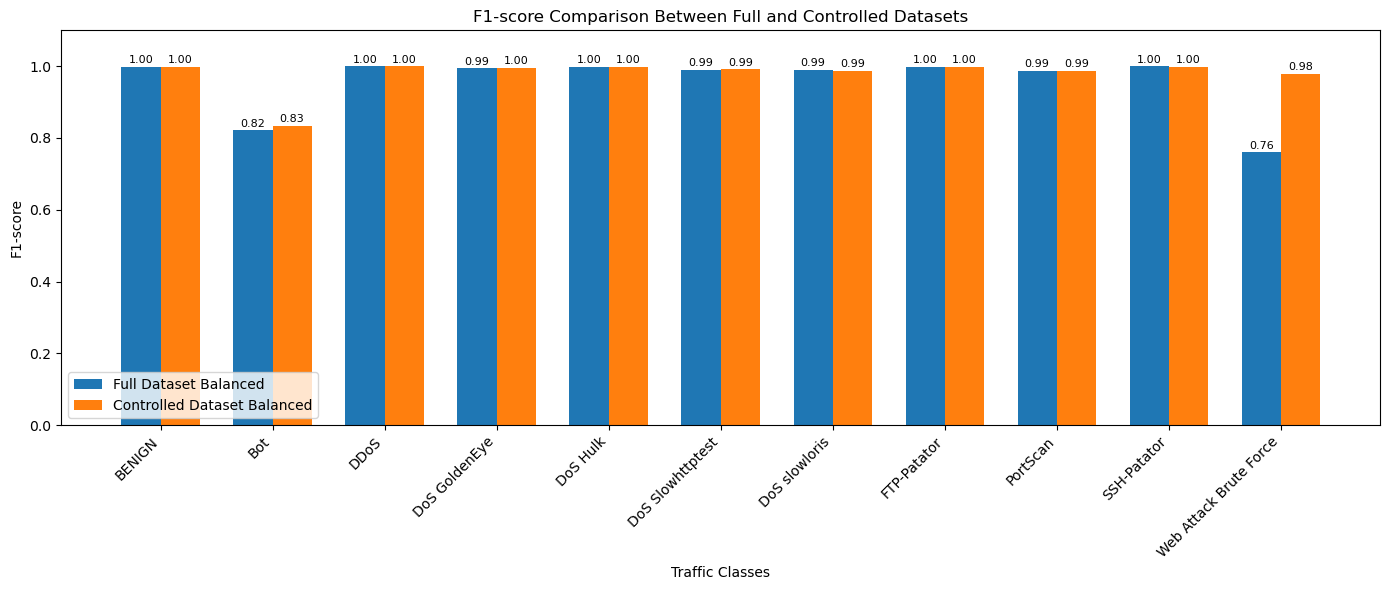

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Generate classification reports
full_report = classification_report(
    y_test,
    dt_full_balanced_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

controlled_report = classification_report(
    y_test_ctrl,
    dt_controlled_balanced_pred,
    target_names=label_encoder_controlled.classes_,
    output_dict=True,
    zero_division=0
)

# Common classes
common_classes = list(label_encoder_controlled.classes_)

# Extract F1-scores
full_f1 = [full_report[label]["f1-score"] for label in common_classes]
controlled_f1 = [controlled_report[label]["f1-score"] for label in common_classes]

# Positions
x = np.arange(len(common_classes))
width = 0.35

# Create figure
plt.figure(figsize=(14,6))

# Bars
bars1 = plt.bar(
    x - width/2,
    full_f1,
    width,
    label="Full Dataset Balanced"
)

bars2 = plt.bar(
    x + width/2,
    controlled_f1,
    width,
    label="Controlled Dataset Balanced"
)

# Add values on top of bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        fontsize=8
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        fontsize=8
    )

# Labels and title
plt.title("F1-score Comparison Between Full and Controlled Datasets")
plt.xlabel("Traffic Classes")
plt.ylabel("F1-score")

# Formatting
plt.xticks(x, common_classes, rotation=45, ha="right")
plt.ylim(0, 1.1)

plt.legend(
    loc='lower left'
)
plt.tight_layout()

# Show graph
plt.show()

The results show that most classes keep very similar F1-scores between both datasets. Only the Web Attack Brute Force class presents a more noticeable improvement in the Controlled Dataset. This indicates that reducing the dataset to 11 classes did not significantly improve the overall detection performance for most attacks.

<h3>9.3 Tuning Decision Tree models</h3>

In [63]:
# Decision Tree Full Dataset Balanced - Tuned for rare classes
dt_full_balanced_tuned = DecisionTreeClassifier(
    criterion="entropy",
    class_weight="balanced",
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42
)

dt_full_balanced_tuned_pred = evaluate_classification_model(
    "Decision Tree",
    "Full Dataset Balanced Tuned",
    dt_full_balanced_tuned,
    X_train,
    X_test,
    y_train,
    y_test,
    label_encoder.classes_
)

Decision Tree - Full Dataset Balanced Tuned
Training time: 26.48 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    419012
                     Bot       0.84      0.83      0.83       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       0.99      0.99      0.99      2057
                DoS Hulk       1.00      1.00      1.00     34569
        DoS Slowhttptest       0.99      0.99      0.99      1046
           DoS slowloris       0.99      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      0.86      0.92         7
                PortScan       0.99      0.99      0.99     18139
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.72      0.74      0.73       294
We

A second tuned Decision Tree model was tested using criterion="log_loss" and min_samples_split=3. The aim was to check whether a different split criterion could slightly improve rare-class detection while keeping the model simple and fast. The class_weight="balanced" parameter was kept because the full dataset remains highly imbalanced.

In [64]:
dt_full_balanced_tuned_2 = DecisionTreeClassifier(
    criterion="log_loss",
    class_weight="balanced",
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42
)

dt_full_balanced_tuned_2_pred = evaluate_classification_model(
    "Decision Tree",
    "Full Dataset Balanced Tuned 2",
    dt_full_balanced_tuned_2,
    X_train,
    X_test,
    y_train,
    y_test,
    label_encoder.classes_
)

Decision Tree - Full Dataset Balanced Tuned 2
Training time: 25.88 seconds
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    419012
                     Bot       0.87      0.83      0.85       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       0.99      0.99      0.99      2057
                DoS Hulk       1.00      1.00      1.00     34569
        DoS Slowhttptest       0.99      0.99      0.99      1046
           DoS slowloris       0.99      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      0.86      0.92         7
                PortScan       0.99      0.99      0.99     18139
             SSH-Patator       1.00      1.00      1.00       644
  Web Attack Brute Force       0.73      0.75      0.74       294


In [65]:
# Create final comparison table with all model results
all_results = pd.DataFrame(model_results)

# Sort by Macro F1-score
all_results_sorted = all_results.sort_values(
    by="Macro F1-score",
    ascending=False
).reset_index(drop=True)

# Display final sorted comparison table
all_results_sorted

,Model Key,Model,Version,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score,Training Time (seconds)
0,Random Forest - Controlled Dataset,Random Forest,Controlled Dataset,0.998659,0.986462,0.975224,0.980467,0.998650,74.565284
1,Random Forest - Controlled Dataset Balanced,Random Forest,Controlled Dataset Balanced,0.998663,0.986000,0.974516,0.979868,0.998654,66.563557
2,Decision Tree - Controlled Dataset Balanced,Decision Tree,Controlled Dataset Balanced,0.998560,0.979904,0.978568,0.979232,0.998559,31.630859
3,Decision Tree - Controlled Dataset,Decision Tree,Controlled Dataset,0.998308,0.977863,0.979155,0.978493,0.998308,48.364473
4,Random Forest - Capped Dataset,Random Forest,Capped Dataset,0.988431,0.945360,0.900638,0.916580,0.988055,1.090462
5,Decision Tree - Full Dataset Balanced Tuned 2,Decision Tree,Full Dataset Balanced Tuned 2,0.998372,0.916101,0.903544,0.909394,0.998367,25.884818
6,Decision Tree - Capped Dataset Balanced,Decision Tree,Capped Dataset Balanced,0.985996,0.915195,0.904704,0.909033,0.986151,0.685288
7,Decision Tree - Full Dataset Balanced Tuned,Decision Tree,Full Dataset Balanced Tuned,0.998407,0.911317,0.902063,0.906311,0.998408,26.480332
8,Decision Tree - Capped Dataset,Decision Tree,Capped Dataset,0.985048,0.903995,0.904846,0.903890,0.985371,0.576450
9,Random Forest - Capped Dataset Balanced,Random Forest,Capped Dataset Balanced,0.988296,0.945059,0.883821,0.898445,0.987847,1.229833


### Tuned Decision Tree Models Overview
The tuning tested different split criteria and minimum split values to check whether the Decision Tree could improve rare-class detection while keeping a low runtime. The class_weight="balanced" parameter was kept because the dataset is highly imbalanced and minority attack classes need additional importance during training.

In [66]:
import pandas as pd
from sklearn.metrics import classification_report

# Generate report for the selected tuned model
report = classification_report(
    y_test,
    dt_full_balanced_tuned_2_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
    output_dict=True
)

# Classes removed from controlled dataset
removed_classes = [
    "Heartbleed",
    "Infiltration",
    "Web Attack Sql Injection",
    "Web Attack XSS"
]
# Create dataframe
removed_metrics = pd.DataFrame([
    {
        "Class": cls,
        "Precision": round(report[cls]["precision"], 2),
        "Recall": round(report[cls]["recall"], 2),
        "F1-score": round(report[cls]["f1-score"], 2),
        "Support": int(report[cls]["support"])
    }
    for cls in removed_classes
])
# Display table
removed_metrics

,Class,Precision,Recall,F1-score,Support
0,Heartbleed,1.00,1.00,1.00,2
1,Infiltration,1.00,0.86,0.92,7
2,Web Attack Sql Injection,0.75,0.75,0.75,4
3,Web Attack XSS,0.43,0.41,0.42,130


### Comparison of Rare Attack Classes

The tuned models produced small improvements for some rare attack classes. The best overall result was achieved by the Full Dataset Balanced Tuned 2 model using criterion="log_loss".

For the rare classes, Heartbleed achieved an F1-score of 1.00, while Infiltration achieved an F1-score of approximately 0.92 despite having very low support.

Web Attack Sql Injection improved from an F1-score of 0.55 to 0.75. Web Attack XSS remained difficult to classify and reached approximately 0.42 F1-score.

These results show that tuning slightly improved the model’s ability to detect some rare attacks without reducing the performance of the main traffic classes.

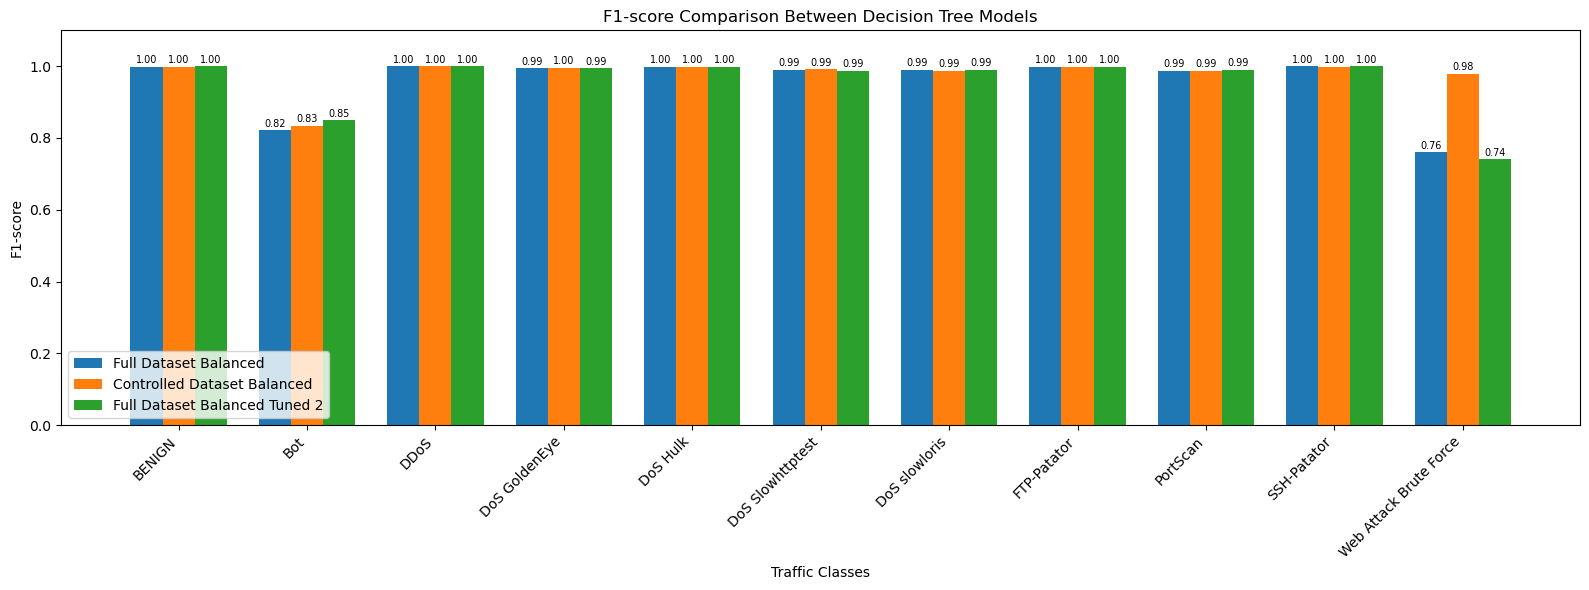

In [67]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Reports generated from model predictions
full_balanced_report = classification_report(
    y_test,
    dt_full_balanced_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

controlled_balanced_report = classification_report(
    y_test_ctrl,
    dt_controlled_balanced_pred,
    target_names=label_encoder_controlled.classes_,
    output_dict=True,
    zero_division=0
)

tuned_2_report = classification_report(
    y_test,
    dt_full_balanced_tuned_2_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

# Common classes between full and controlled datasets
common_classes = list(label_encoder_controlled.classes_)

# Extract F1-scores automatically
full_balanced_f1 = [full_balanced_report[cls]["f1-score"] for cls in common_classes]
controlled_balanced_f1 = [controlled_balanced_report[cls]["f1-score"] for cls in common_classes]
tuned_2_f1 = [tuned_2_report[cls]["f1-score"] for cls in common_classes]

# Plot
x = np.arange(len(common_classes))
width = 0.25

plt.figure(figsize=(16, 6))

bars1 = plt.bar(x - width, full_balanced_f1, width, label="Full Dataset Balanced")
bars2 = plt.bar(x, controlled_balanced_f1, width, label="Controlled Dataset Balanced")
bars3 = plt.bar(x + width, tuned_2_f1, width, label="Full Dataset Balanced Tuned 2")

# Add values on top
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            fontsize=7
        )

plt.title("F1-score Comparison Between Decision Tree Models")
plt.xlabel("Traffic Classes")
plt.ylabel("F1-score")
plt.xticks(x, common_classes, rotation=45, ha="right")
plt.ylim(0, 1.1)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

The graph shows that all three Decision Tree models achieved very similar F1-scores across most of the shared traffic classes. This indicates that reducing or tuning the dataset did not produce major changes in the detection performance for the main attack categories.

The largest difference appears in the Web Attack Brute Force class, where the Controlled Dataset Balanced model achieved the highest F1-score. However, the Tuned Full Dataset Balanced model still maintained acceptable performance while preserving the additional rare attack classes removed from the controlled dataset.

This is important because the tuned full dataset model allows the IDS to detect four extra attack categories: Heartbleed, Infiltration, Web Attack Sql Injection and Web Attack XSS. Even though some of these attacks achieved lower support and lower F1-scores, keeping them in the dataset increases the attack coverage of the IDS and allows the system to recognise a broader range of malicious behaviours.

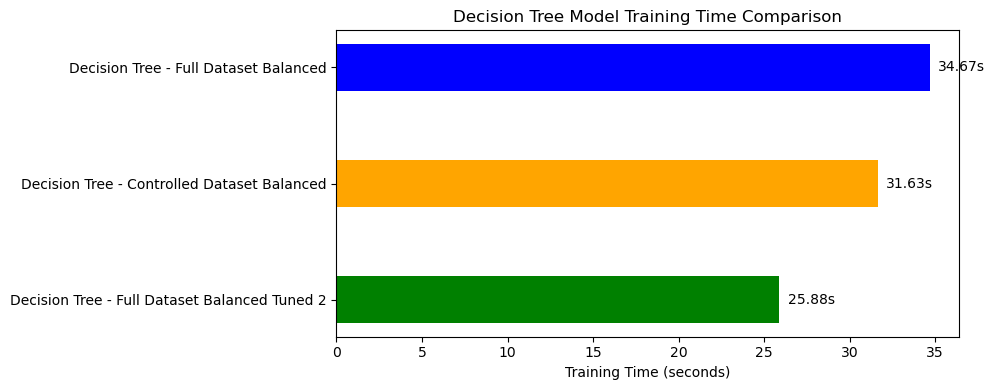

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# Create dataframe
results_df = pd.DataFrame(model_results)

# Select models
runtime_df = results_df[
    results_df["Model Key"].isin([
        "Decision Tree - Controlled Dataset Balanced",
        "Decision Tree - Full Dataset Balanced",
        "Decision Tree - Full Dataset Balanced Tuned 2"
    ])
]

# Sort by runtime
runtime_df = runtime_df.sort_values(
    by="Training Time (seconds)",
    ascending=True
)

# Define colors matching previous graph style
colors = ["green", "orange", "blue"]

# Plot
plt.figure(figsize=(10, 4))

bars = plt.barh(
    runtime_df["Model Key"],
    runtime_df["Training Time (seconds)"],
    color=colors,
    height=0.4
)

# Add values beside bars
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}s",
        va='center'
    )

plt.xlabel("Training Time (seconds)")
plt.title("Decision Tree Model Training Time Comparison")

plt.tight_layout()
plt.show()

The graph shows that the Tuned 2 Decision Tree achieved the lowest training time while still maintaining strong classification performance, demonstrating that the parameter tuning improved computational efficiency without reducing the overall detection capability of the model.

---

<h3>9.4 Confusion Matrix</h3>

### Decision Tree Controlled Dataset - Confusion Matrix

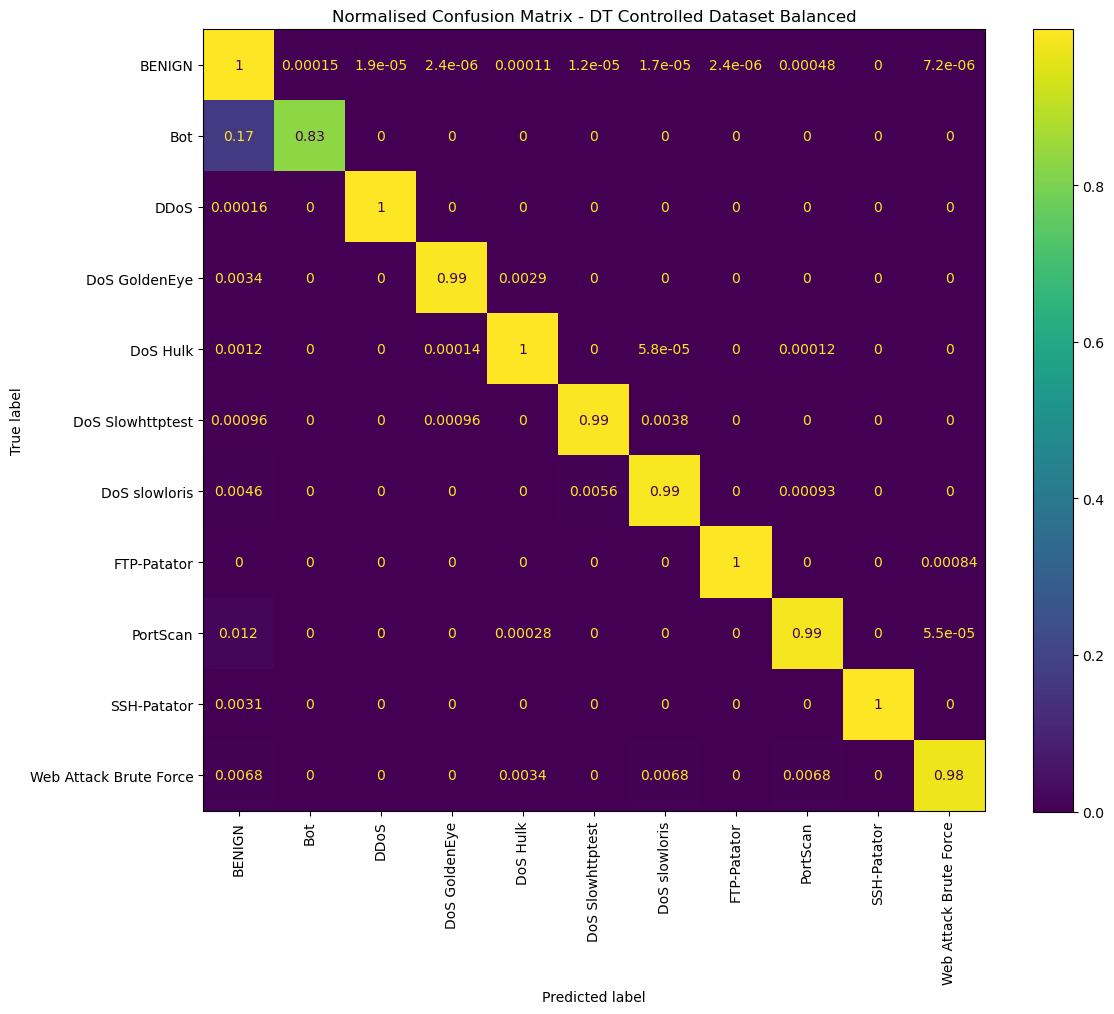

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test_ctrl,
    dt_controlled_balanced_pred,
    display_labels=label_encoder_controlled.classes_,
    xticks_rotation=90,
    normalize='true',
    ax=ax
)

plt.title("Normalised Confusion Matrix - DT Controlled Dataset Balanced")
plt.tight_layout()
plt.show()

The normalised confusion matrix for the Controlled Dataset Balanced Decision Tree shows strong classification performance across the 11 selected traffic classes.

Most values are concentrated on the main diagonal, which means that most records were correctly classified. Classes such as BENIGN, DDoS, FTP-Patator and SSH-Patator achieved almost perfect classification rates.

The Bot class performed weaker than most other classes. Around 15% of Bot traffic was misclassified as BENIGN, suggesting that some Bot behaviour may look similar to normal traffic.

Web Attack Brute Force performed well, with only small misclassifications into other classes. Overall, the confusion matrix confirms that the Controlled Dataset Balanced Decision Tree is stable and accurate for the 11-class controlled scenario.

However, this model does not include the four rare classes removed from the controlled dataset, so it has lower attack coverage than the full dataset tuned model.

### Decision Tree Full Dataset (Tuned 2) - Confusion Matrix

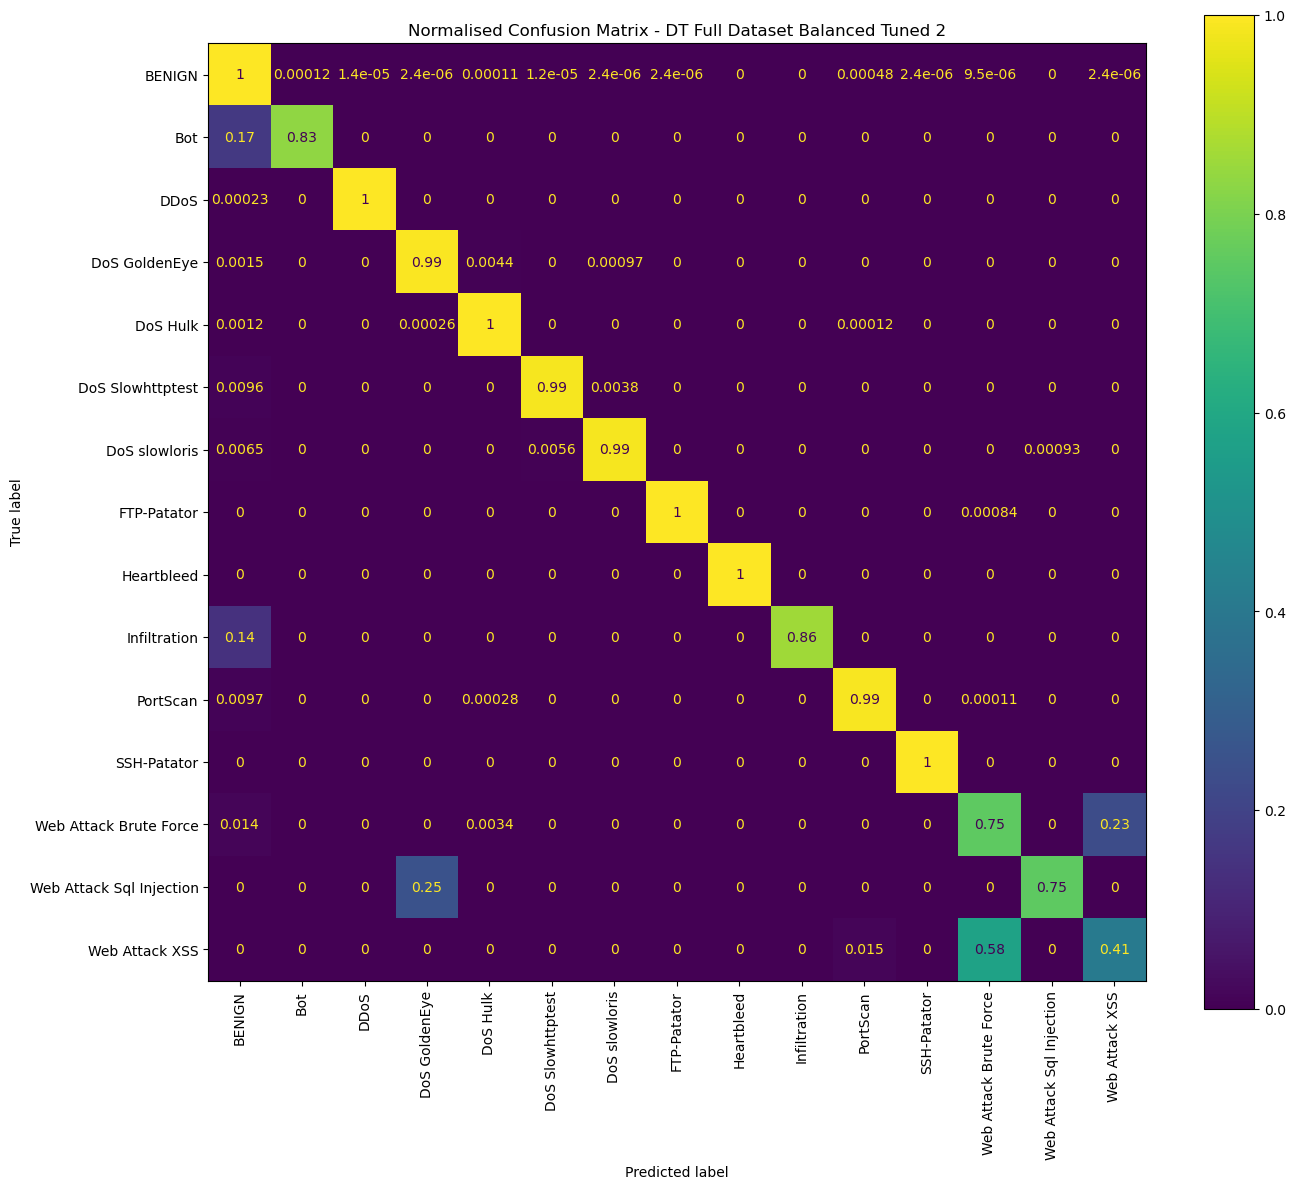

In [70]:
fig, ax = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_full_balanced_tuned_2_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
    normalize='true',
    ax=ax
)

plt.title("Normalised Confusion Matrix - DT Full Dataset Balanced Tuned 2")
plt.tight_layout()
plt.show()

The confusion matrix of the Tuned 2 Decision Tree model shows that the model maintained very strong classification performance across the main traffic classes, similarly to the Controlled Dataset Balanced model. Most values remain concentrated on the diagonal, indicating that the majority of records were correctly classified.

The overall behaviour of the shared 11 classes did not change significantly compared to the controlled model. Classes such as BENIGN, DDoS, DoS Hulk, FTP-Patator and SSH-Patator continued achieving near-perfect classification rates close to 1.00. The Bot class still remained the most difficult among the common classes, with around 16% of Bot traffic being incorrectly classified as BENIGN traffic, which is very similar to the controlled dataset results.

The main advantage of the Tuned 2 model is the inclusion of four additional rare attack classes: Heartbleed, Infiltration, Web Attack Sql Injection and Web Attack XSS. Heartbleed achieved perfect classification, while Infiltration also performed strongly despite its very low support value, showing that the model was able to learn these patterns successfully.

The Web Attack classes remained more difficult to classify. Web Attack Sql Injection achieved an F1-score of approximately 0.75, while Web Attack XSS remained the weakest class with an F1-score of approximately 0.42.

Overall, the confusion matrix indicates that adding the extra attack classes did not significantly reduce the performance of the main traffic categories, while also increasing the attack coverage capability of the IDS.

---

## SMOTE Consideration

SMOTE was considered as a possible technique to address class imbalance in the multiclass IDS dataset. SMOTE creates synthetic examples for minority classes, which can help models learn rare classes more effectively.

However, SMOTE was not selected as the main strategy at this stage.

First, the cleaned dataset is already very large, with more than two million records. Applying SMOTE to the full training set could significantly increase the number of rows and memory usage. This would make the modelling process heavier and would go against the lightweight objective of the IDS prototype.

Second, some of the original attack classes had extremely low support, such as Heartbleed, Infiltration and Web Attack Sql Injection. Creating synthetic data from very small classes may not represent real network behaviour reliably.

For this reason, the project prioritised controlled multiclass modelling, class weighting and capped stratified sampling as more practical approaches. These methods keep the experiments computationally manageable while still addressing the imbalance problem in a transparent way.

Later in the evaluation, Decision Tree tuning was also used as a more practical alternative to SMOTE. This allowed the project to keep the full dataset and preserve rare attack classes without creating synthetic traffic records.

---

### Final Model Selection

The Decision Tree Full Dataset Balanced Tuned 2 model was selected as the final IDS model because it achieved the best balance between detection performance, attack coverage, interpretability and runtime efficiency.

Although the Controlled Dataset models achieved slightly higher Macro F1-scores, they removed four rare attack classes: Heartbleed, Infiltration, Web Attack Sql Injection and Web Attack XSS. This improved metric stability, but reduced the coverage of the IDS.

For an intrusion detection system, attack coverage is important because rare attacks may still be security-relevant. Removing them completely would mean the model could never predict those classes.

The Tuned 2 Decision Tree kept all 15 traffic classes and maintained very strong F1-scores for the main classes. It also partially detected the rare attack classes, with Heartbleed reaching 1.00 F1-score, Infiltration around 0.92, Web Attack Sql Injection around 0.75 and Web Attack XSS around 0.42.

The model also achieved the lowest training time among the evaluated full dataset Decision Tree models, with approximately 25 seconds in this final run. This supports the lightweight objective of the project.

Therefore, the Decision Tree Full Dataset Balanced Tuned 2 model was selected as the final model for the IDS prototype.

---

# 10. Deployment Preparation

The purpose of this section is to prepare the final selected model for reuse outside the notebook.

At this stage, the project is not deploying a full production IDS. Instead, the goal is to prepare the main objects needed for a lightweight prototype or future Streamlit dashboard.

The final selected model is:

**Decision Tree - Full Dataset Balanced Tuned 2**

This model was selected because it preserved all 15 traffic classes, maintained strong performance on the main classes, detected some rare attacks, had low training time, and remained simple and interpretable.

The deployment preparation includes:

- saving the final trained model;
- saving the label encoder;
- saving the feature list used by the model;
- creating a simple prediction function;
- testing the function with sample network flows;
- analysing feature importance for interpretability.

## 10.1 Save Final Model and Preprocessing Objects

The final trained model and important preprocessing objects are saved using Joblib.

This is important because the model can later be loaded into a separate Python file or Streamlit dashboard without retraining everything again.

The objects saved are:

- the final Decision Tree model;
- the label encoder used to convert numeric predictions back into original class names;
- the list of features used during training.

Although the final Decision Tree model does not require scaling, saving the feature list is essential because new input data must follow the same feature structure used during training.

In [71]:
import joblib

# Save final selected model
joblib.dump(dt_full_balanced_tuned_2, "final_decision_tree_ids_model.pkl")

# Save label encoder used for the full 15-class dataset
joblib.dump(label_encoder, "label_encoder.pkl")

# Save the feature list used by the final model
joblib.dump(list(X_train.columns), "model_features.pkl")

print("Final model and preprocessing objects saved successfully.")

Final model and preprocessing objects saved successfully.


The final model and supporting objects were saved successfully as Joblib files: final_decision_tree_ids_model.pkl, label_encoder.pkl and model_features.pkl. This means the trained IDS model, the original class label mapping and the required input feature structure can be reused later without retraining the model.

## 10.2 Load Saved Objects for Testing

To confirm that the saved files work correctly, the model, label encoder and feature list are loaded again.

This simulates how a future dashboard or prototype would load the trained model before making predictions.

In [72]:
# Load saved model and objects
loaded_model = joblib.load("final_decision_tree_ids_model.pkl")
loaded_label_encoder = joblib.load("label_encoder.pkl")
loaded_feature_list = joblib.load("model_features.pkl")

print("Saved objects loaded successfully.")
print("Number of model features:", len(loaded_feature_list))

Saved objects loaded successfully.
Number of model features: 39


The saved objects were loaded successfully, and the saved feature list contains 39 model features. This confirms that the final model can be stored and reused outside the training workflow while keeping the same feature structure used during training.

## 10.3 Prediction Function

A prediction function is created to simulate how the IDS model would classify new network flow records.

The function receives input data, keeps only the required model features in the correct order, predicts the encoded class labels, and then converts the predictions back into readable traffic class names.

This step is useful because a future dashboard would follow a similar process when a user uploads a CSV file containing network flow data.

In [73]:
def predict_network_traffic(input_data, model, label_encoder, feature_list):
    """
    Predict network traffic classes using the final selected IDS model.

    Parameters:
    input_data: dataframe containing network flow features
    model: trained machine learning model
    label_encoder: fitted label encoder used for target labels
    feature_list: list of features used during model training

    Returns:
    predicted traffic labels as readable class names
    """
    
    # Keep only the required features and ensure correct column order
    input_data = input_data[feature_list]
    
    # Predict encoded class labels
    predictions_encoded = model.predict(input_data)
    
    # Convert numeric predictions back to original label names
    predictions_labels = label_encoder.inverse_transform(predictions_encoded)
    
    return predictions_labels

The prediction function provides a simple reusable workflow for classifying new network traffic samples. This supports the prototype objective of the project.

## 10.4 Test Prediction Function with Sample Flows

To test the prediction function, a small sample of records is selected from the test set.

This does not represent a full deployment scenario, but it demonstrates that the saved model can receive network flow data and return readable IDS predictions.

In [74]:
# Select a small sample from the test set
sample_flows = X_test.head(10)

# Predict traffic labels using the loaded model
sample_predictions = predict_network_traffic(
    input_data=sample_flows,
    model=loaded_model,
    label_encoder=loaded_label_encoder,
    feature_list=loaded_feature_list
)

# Display predictions
sample_predictions

array(['BENIGN', 'PortScan', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN',
       'BENIGN', 'DDoS', 'BENIGN', 'BENIGN'], dtype=object)

The loaded model returned readable traffic labels for the 10 sample flows. In this sample, the model predicted mostly BENIGN traffic, but also identified one PortScan flow and one DDoS flow. This confirms that the saved model workflow can return both normal and attack-class predictions.

## 10.5 Compare Actual and Predicted Labels

The predicted labels are compared with the actual labels from the test set.

This provides a simple demonstration of how the model behaves on example network flows.

In [75]:
# Convert actual encoded labels back into original class names
actual_labels = loaded_label_encoder.inverse_transform(y_test[:10])

# Create comparison table
prediction_demo_results = pd.DataFrame({
    "Actual Label": actual_labels,
    "Predicted Label": sample_predictions
})

prediction_demo_results

,Actual Label,Predicted Label
0,BENIGN,BENIGN
1,PortScan,PortScan
2,BENIGN,BENIGN
3,BENIGN,BENIGN
4,BENIGN,BENIGN
5,BENIGN,BENIGN
6,BENIGN,BENIGN
7,DDoS,DDoS
8,BENIGN,BENIGN
9,BENIGN,BENIGN


The comparison table shows that the sample included BENIGN, PortScan and DDoS records, and the predicted labels matched the actual labels for all 10 examples. This is useful for demonstration purposes because it shows how the model output could be presented in a simple dashboard-style table.

## 10.6 Create Sample Prediction Output Table

A sample output table is created to show how predictions could appear in a simple IDS prototype.

The actual label, predicted label and prediction status are displayed here to keep the output easy to understand.

In [76]:
# Add a simple status column to highlight whether the prediction is correct
prediction_demo_results["Correct Prediction"] = (
    prediction_demo_results["Actual Label"] == prediction_demo_results["Predicted Label"]
)

prediction_demo_results

,Actual Label,Predicted Label,Correct Prediction
0,BENIGN,BENIGN,True
1,PortScan,PortScan,True
2,BENIGN,BENIGN,True
3,BENIGN,BENIGN,True
4,BENIGN,BENIGN,True
5,BENIGN,BENIGN,True
6,BENIGN,BENIGN,True
7,DDoS,DDoS,True
8,BENIGN,BENIGN,True
9,BENIGN,BENIGN,True


In this small sample, the predicted labels matched the actual labels. This does not replace the full model evaluation, but it demonstrates that the saved model and prediction function work correctly and can produce readable IDS outputs.

The sample output also shows that the prototype format can support both benign and attack labels, such as PortScan and DDoS. In a future Streamlit dashboard, a similar table could be used to show traffic classifications, correct predictions and suspicious flow summaries.

## 10.7 Feature Importance

One reason for selecting Decision Tree as the final model is interpretability.

Decision Tree models provide feature importance values, which help identify which network flow features were most useful for classification.

This is important for an IDS prototype because it helps explain which traffic characteristics influenced the model predictions.

In [77]:
# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_full_balanced_tuned_2.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display top 15 most important features
feature_importance.head(15)

,Feature,Importance
0,Destination Port,0.458956
1,Init_Win_bytes_backward,0.120981
2,Bwd Packet Length Max,0.074098
3,min_seg_size_forward,0.066507
4,Bwd Packets/s,0.058748
5,Flow Bytes/s,0.032986
6,Fwd Packet Length Max,0.023679
7,Bwd IAT Mean,0.023332
8,Total Length of Fwd Packets,0.023327
9,Bwd Packet Length Min,0.021191


The feature importance table shows that Destination Port was the most influential feature, with an importance score of approximately 0.459. The next most important features were Init_Win_bytes_backward, Bwd Packet Length Max, min_seg_size_forward and Bwd Packets/s.

This suggests that the final Decision Tree model relied strongly on service/port information, TCP window behaviour, packet size characteristics and flow-rate patterns when separating benign and malicious traffic.

## 10.8 Feature Importance Visualisation

A bar chart is used to visualise the top 15 most important features from the final model.

This makes the model easier to interpret and supports the explanation of why Decision Tree is suitable for a lightweight IDS prototype.

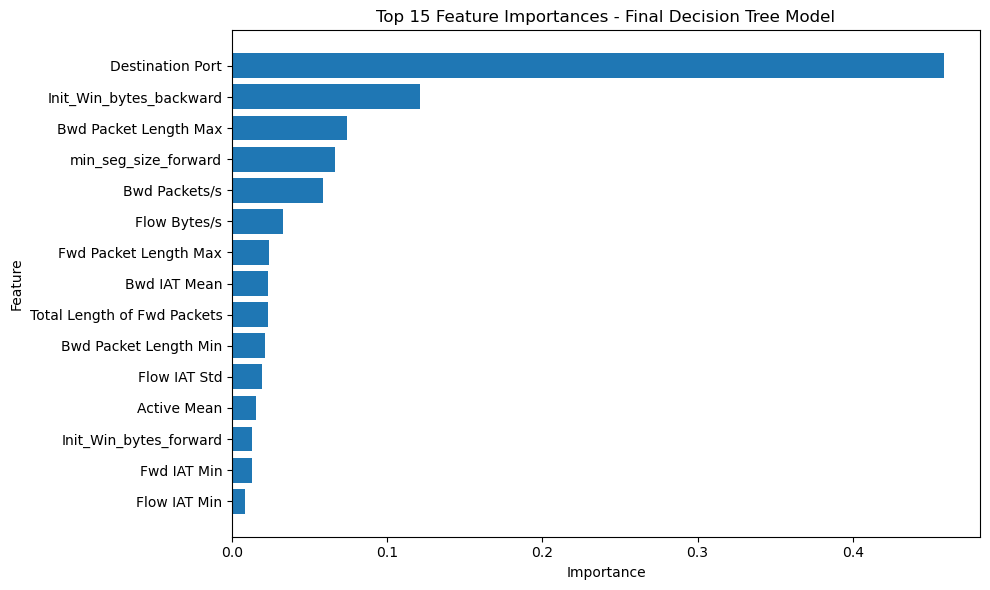

In [78]:
import matplotlib.pyplot as plt

# Select top 15 features
top_features = feature_importance.head(15)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Final Decision Tree Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The feature importance chart shows that Destination Port was clearly the most influential feature in the final Decision Tree model, with a much higher importance score than the remaining variables. This is reasonable in an IDS context because different services, protocols and attack behaviours are often associated with specific ports.

The next most important features were Init_Win_bytes_backward, Bwd Packet Length Max, min_seg_size_forward, Bwd Packets/s and Flow Bytes/s. These variables relate to TCP window behaviour, packet size, segment size and traffic rate, which are useful indicators of network flow behaviour.

This supports the interpretability of the selected Decision Tree model because the model is not only producing predictions, but also showing which network characteristics were most influential in the classification process.

## 10.9 Deployment Workflow Explanation

The saved model and prediction function provide the foundation for a future lightweight IDS dashboard.

A possible deployment workflow would be:

1. The user uploads a CSV file containing network flow records.
2. The system checks and aligns the input columns with the saved feature list.
3. The saved Decision Tree model predicts the traffic class.
4. The label encoder converts numeric predictions into readable class names.
5. The dashboard displays predicted traffic labels, highlights attack predictions such as PortScan or DDoS, and provides a summary of benign versus suspicious flows.

This prototype workflow is suitable for a small organisation or MSP-style environment because it is simple, lightweight and based on open-source Python tools.

In this notebook, this process was tested using 10 records from the test set. The same logic could be reused in Streamlit by replacing the test sample with a user-uploaded CSV file.

## 10.10 Deployment Limitations

This deployment preparation is only a prototype step and not a full production IDS.

The current model does not capture live network packets directly. Instead, it expects structured network flow data that has already been converted into the same 39 selected features used during training.

This means that any future input file must contain the same 39 selected features in the correct format. If the uploaded data contains missing, renamed or extra columns, an additional preprocessing step would be required before prediction.

The model was trained on CICIDS2017, which is a public historical dataset. Therefore, future deployment would require testing with newer data and possibly retraining the model to detect more recent attack patterns.

The model should also be used as a decision-support tool rather than a complete replacement for human security analysis or enterprise security tools.

## 10.11 Deployment Preparation Summary

This section prepared the final selected IDS model for future deployment.

The final Decision Tree Full Dataset Balanced Tuned 2 model was saved, together with the label encoder and the 39-feature input list. A prediction function was created and tested using 10 sample flows from the test set.

In the sample output, the model correctly predicted BENIGN, PortScan and DDoS examples. Feature importance was also analysed, showing that Destination Port was the most influential variable, followed by TCP window, packet length, segment size and flow-rate related features.

Overall, this deployment preparation shows that the final model can be reused outside the notebook and provides the technical foundation for a future Streamlit dashboard or lightweight IDS prototype.

---

<h1 style="text-align: center;">10. Conclusion</h1>

This project explored the use of machine learning techniques for the development of a lightweight Intrusion Detection System (IDS) using the CICIDS2017 dataset. Different dataset versions, balancing approaches and classification algorithms were evaluated in order to identify the most suitable model for multiclass network intrusion detection.

The experiments showed that Random Forest and Decision Tree achieved significantly better results than Logistic Regression for this dataset. Logistic Regression struggled with the nonlinear and imbalanced nature of the traffic data, especially for minority attack classes, resulting in lower macro F1-scores and much longer training times.

Decision Tree models demonstrated strong overall performance while maintaining lower computational cost. Different dataset reduction strategies were tested, including capped and controlled datasets, in order to improve training efficiency and class balance. The controlled dataset approach produced very high F1-scores for the shared traffic classes by removing extremely rare classes and reducing the classification problem from 15 classes to 11 classes.

However, removing rare attack classes completely would reduce the IDS attack coverage. For this reason, additional experiments were performed using the full dataset balanced models to preserve classes such as Heartbleed, Infiltration, Web Attack SQL Injection and Web Attack XSS. Although some of these classes achieved lower F1-scores due to very low support values, the models were still capable of partially detecting these attacks.

After tuning the Decision Tree parameters, the Decision Tree Full Dataset Balanced Tuned 2 model achieved the best balance between classification performance, attack coverage and runtime efficiency among the tested models. The tuned model maintained strong detection rates for the main traffic classes, preserved detection capability for the additional attack classes and also achieved the best training runtime among the evaluated full dataset Decision Tree models.

The final model was not selected only by the highest Macro F1-score. The project also considered runtime, interpretability, lightweight deployment suitability and attack coverage. This is why the Decision Tree Full Dataset Balanced Tuned 2 model was selected instead of the controlled dataset models, even though the controlled models had slightly higher macro scores.

Overall, the results demonstrate that Decision Tree models can provide an effective and computationally efficient solution for lightweight IDS environments while still maintaining broad attack detection coverage.

<h1 style="text-align: center;">11. References</h3>